# LEiDA, EiDA and state-dynamics analysis

This notebook reproduces the retained LEiDA/EiDA figures and tables from the report. It displays results only; it does not write tables or figures to disk.


In [14]:
from pathlib import Path
from unittest.mock import patch

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

from IPython.display import Markdown, display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import PercentFormatter
from nichord.chord import plot_chord
from nilearn import plotting
from nilearn.datasets import load_mni152_brain_mask, load_mni152_template
from nilearn.image import resample_to_img
from scipy.optimize import linear_sum_assignment
from scipy.signal import hilbert
from scipy.special import expit
from sklearn.cluster import kmeans_plusplus
from sklearn.metrics import confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from statsmodels.stats.multitest import multipletests


## Data and settings


In [ ]:
ROOT = #INSERT ROOT DIRECTORY
INPUT_FILE = #ROOT / PATH TO PARCELLATED TIME SERIES
ATLAS_FILE = (
    #ROOT / PATH TO ATLAS FILE
)
LABEL_FILE = (
    #ROOT / PATH TO NETWORK LABEL FILE
)

TR = 1.25
K_VALUES = range(3, 8)
RANDOM_SEED = 50
N_PERMUTATIONS = 100_000

metadata_columns = [
    "scan_ids", "subjects", "sessions", "timepoints", "treatment",
    "qids_pre", "qids_post", "qids_reduction", "qids_percent_reduction",
    "responder_50pct", "achieved_remission", "response_status", "remission_status",
]

with np.load(INPUT_FILE, allow_pickle=False) as data:
    timeseries = data["timeseries"].astype(np.float32)
    scan_info = pd.DataFrame({name: data[name].copy() for name in metadata_columns})

n_scans, n_timepoints, n_parcels = timeseries.shape


## Instantaneous phase eigenmodes


In [16]:
def phase_eigenmodes(scan):
    scan = scan.astype(float) - scan.mean(axis=0, keepdims=True)
    phase = np.angle(hilbert(scan, axis=0))
    cosine = np.cos(phase)
    sine = np.sin(phase)

    gram = np.empty((len(phase), 2, 2))
    gram[:, 0, 0] = np.sum(cosine**2, axis=1)
    gram[:, 0, 1] = np.sum(cosine * sine, axis=1)
    gram[:, 1, 0] = gram[:, 0, 1]
    gram[:, 1, 1] = np.sum(sine**2, axis=1)
    eigenvalues, eigenvectors = np.linalg.eigh(gram)
    eigenvalues = np.clip(eigenvalues, 0, None)

    lambda2, lambda1 = eigenvalues[:, 0], eigenvalues[:, 1]
    q2, q1 = eigenvectors[:, :, 0], eigenvectors[:, :, 1]
    w1 = cosine * q1[:, 0, None] + sine * q1[:, 1, None]
    w2 = cosine * q2[:, 0, None] + sine * q2[:, 1, None]
    v1 = w1 / np.sqrt(lambda1[:, None])
    return v1, w1, w2, lambda1, lambda2


n_observations = n_scans * n_timepoints
V1 = np.empty((n_observations, n_parcels), dtype=np.float32)
W1 = np.empty_like(V1)
W2 = np.empty_like(V1)
lambda1 = np.empty(n_observations, dtype=np.float32)
lambda2 = np.empty(n_observations, dtype=np.float32)

for scan_index, scan in enumerate(timeseries):
    rows = slice(scan_index * n_timepoints, (scan_index + 1) * n_timepoints)
    V1[rows], W1[rows], W2[rows], lambda1[rows], lambda2[rows] = phase_eigenmodes(scan)

V1 /= np.linalg.norm(V1, axis=1, keepdims=True)
time_info = scan_info.loc[scan_info.index.repeat(n_timepoints)].reset_index(drop=True)
time_info["frame"] = np.tile(np.arange(n_timepoints), n_scans)


## LEiDA clustering and model selection


In [17]:
def diametrical_initialisation(X, n_clusters, rng):
    centroids = np.empty((n_clusters, X.shape[1]), dtype=X.dtype)
    centroids[0] = X[rng.integers(len(X))]
    distance = 1 - (X @ centroids[0]) ** 2
    for state in range(1, n_clusters):
        probabilities = np.clip(distance, 0, None)
        probabilities /= probabilities.sum()
        centroids[state] = X[rng.choice(len(X), p=probabilities)]
        distance = np.minimum(distance, 1 - (X @ centroids[state]) ** 2)
    return centroids


def diametrical_kmeans(X, n_clusters, seed):
    master_rng = np.random.default_rng(seed)
    best = None
    for _ in range(20):
        rng = np.random.default_rng(master_rng.integers(0, 2**32 - 1))
        centroids = diametrical_initialisation(X, n_clusters, rng)
        labels = np.full(len(X), -1)
        for _ in range(100):
            new_labels = np.argmax((X @ centroids.T) ** 2, axis=1)
            if np.array_equal(new_labels, labels):
                break
            labels = new_labels
            for state in range(n_clusters):
                members = X[labels == state]
                centroids[state] = np.linalg.eigh(members.T @ members)[1][:, -1]
        fit = np.max((X @ centroids.T) ** 2, axis=1).mean()
        if best is None or fit > best[0]:
            best = fit, labels.copy(), centroids.copy()
    return best[1], best[2], best[0]


def axial_silhouette(X, labels, sample_indices):
    sample = X[sample_indices].astype(float)
    sample_labels = labels[sample_indices]
    n_clusters = labels.max() + 1
    mean_distance = np.empty((len(sample), n_clusters))
    within_distance = np.empty(len(sample))
    self_similarity = np.sum(sample**2, axis=1) ** 2
    for state in range(n_clusters):
        members = X[labels == state]
        similarity_sum = np.sum((sample @ (members.T @ members)) * sample, axis=1)
        mean_distance[:, state] = np.clip(1 - similarity_sum / len(members), 0, 1)
        own = sample_labels == state
        within_distance[own] = np.clip(
            1 - (similarity_sum[own] - self_similarity[own]) / (len(members) - 1), 0, 1
        )
    mean_distance[np.arange(len(sample)), sample_labels] = np.inf
    nearest = mean_distance.min(axis=1)
    denominator = np.maximum(within_distance, nearest)
    return np.divide(
        nearest - within_distance,
        denominator,
        out=np.zeros_like(denominator),
        where=denominator > 0,
    ).mean()


def axial_davies_bouldin(X, labels, centroids):
    dispersion = np.array([
        np.mean(1 - (X[labels == state] @ centroids[state]) ** 2)
        for state in range(len(centroids))
    ])
    separation = np.maximum(1 - (centroids @ centroids.T) ** 2, 1e-12)
    ratios = (dispersion[:, None] + dispersion[None, :]) / separation
    np.fill_diagonal(ratios, -np.inf)
    return np.max(ratios, axis=1).mean()


rng = np.random.default_rng(RANDOM_SEED)
silhouette_sample = rng.choice(len(V1), size=min(4000, len(V1)), replace=False)
models = {}
rows = []
for k in K_VALUES:
    labels, centroids, fit = diametrical_kmeans(V1, k, RANDOM_SEED + k)
    models[k] = labels, centroids
    rows.append({
        "K": k,
        "silhouette": axial_silhouette(V1, labels, silhouette_sample),
        "axial_DB": axial_davies_bouldin(V1, labels, centroids),
        "clustering_fit": fit,
    })

selection = pd.DataFrame(rows)
selection["joint_rank"] = (
    selection["silhouette"].rank(ascending=False, method="min")
    + selection["axial_DB"].rank(ascending=True, method="min")
)
BEST_K = int(selection.sort_values(["joint_rank", "K"]).iloc[0]["K"])


### LEiDA model-selection plot


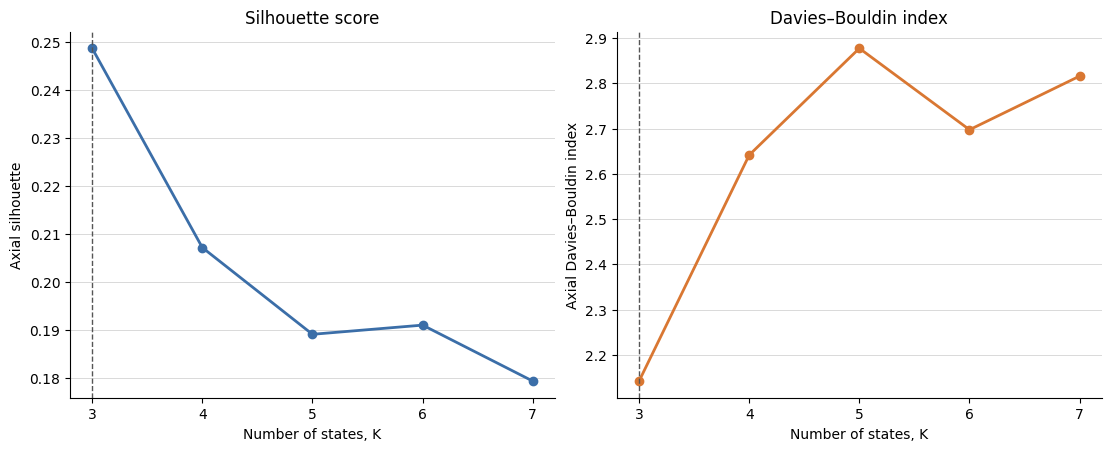

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
for ax, column, title, ylabel, colour in zip(
    axes,
    ["silhouette", "axial_DB"],
    ["Silhouette score", "Davies–Bouldin index"],
    ["Axial silhouette", "Axial Davies–Bouldin index"],
    ["#3B6EA8", "#D97732"],
):
    ax.plot(selection["K"], selection[column], color=colour, marker="o", linewidth=2)
    ax.axvline(BEST_K, color="#555555", linestyle="--", linewidth=1)
    ax.set(title=title, xlabel="Number of states, K", ylabel=ylabel)
    ax.set_xticks(selection["K"])
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)
plt.show()

leida_labels, leida_centroids = models[BEST_K]
occupancy_order = np.argsort(np.bincount(leida_labels, minlength=BEST_K))[::-1]
old_to_new = np.empty(BEST_K, dtype=int)
old_to_new[occupancy_order] = np.arange(BEST_K)
leida_labels = old_to_new[leida_labels]
leida_centroids = leida_centroids[occupancy_order]

final_order = np.array([0, 2, 1])
old_to_new = np.empty(BEST_K, dtype=int)
old_to_new[final_order] = np.arange(BEST_K)
leida_labels = old_to_new[leida_labels]
leida_centroids = leida_centroids[final_order]


## EiDA clustering


In [19]:
def upper_phase_alignment(w1, w2, triangle):
    i, j = triangle
    return (w1[:, i] * w1[:, j] + w2[:, i] * w2[:, j]).astype(np.float32)


def eida_kmeans(w1, w2, l1, l2, n_clusters, seed):
    rng = np.random.default_rng(seed)
    n_observations, n_regions = w1.shape
    triangle = np.triu_indices(n_regions, k=0)
    observation_norm = np.sqrt(np.maximum((l1**2 + l2**2 + n_regions) / 2, 1e-12))
    sample_indices = rng.choice(n_observations, size=min(5000, n_observations), replace=False)
    sample = upper_phase_alignment(w1[sample_indices], w2[sample_indices], triangle)
    sample /= np.linalg.norm(sample, axis=1, keepdims=True)
    best = None

    for _ in range(10):
        centroids = kmeans_plusplus(
            sample,
            n_clusters=n_clusters,
            random_state=int(rng.integers(0, 2**31 - 1)),
        )[0].astype(np.float32)
        labels = np.full(n_observations, -1)
        for _ in range(100):
            new_labels = np.empty(n_observations, dtype=int)
            sums = np.zeros_like(centroids, dtype=np.float64)
            counts = np.zeros(n_clusters, dtype=int)
            similarity_total = 0
            for start in range(0, n_observations, 512):
                stop = min(start + 512, n_observations)
                features = upper_phase_alignment(w1[start:stop], w2[start:stop], triangle)
                similarity = features @ centroids.T
                similarity /= observation_norm[start:stop, None]
                similarity /= np.linalg.norm(centroids, axis=1)[None, :]
                block_labels = np.argmax(similarity, axis=1)
                new_labels[start:stop] = block_labels
                similarity_total += similarity[np.arange(stop - start), block_labels].sum()
                counts += np.bincount(block_labels, minlength=n_clusters)
                for state in np.unique(block_labels):
                    sums[state] += features[block_labels == state].sum(axis=0)
            updated = np.array([sums[state] / counts[state] for state in range(n_clusters)], dtype=np.float32)
            converged = np.array_equal(new_labels, labels)
            labels, centroids = new_labels, updated
            if converged:
                break
        fit = similarity_total / n_observations
        if best is None or fit > best[0]:
            best = fit, labels.copy(), centroids.copy()
    return best[1], best[2], best[0]


eida_labels, eida_centroids_upper, eida_fit = eida_kmeans(
    W1, W2, lambda1, lambda2, BEST_K, RANDOM_SEED
)

triangle = np.triu_indices(n_parcels, k=0)
leida_edge_patterns = np.stack([
    np.outer(centroid, centroid)[triangle] for centroid in leida_centroids
])
matching_similarity = cosine_similarity(leida_edge_patterns, eida_centroids_upper)
leida_match, raw_eida_match = linear_sum_assignment(-matching_similarity)
eida_order = np.empty(BEST_K, dtype=int)
eida_order[leida_match] = raw_eida_match
old_to_new = np.empty(BEST_K, dtype=int)
old_to_new[eida_order] = np.arange(BEST_K)
eida_labels = old_to_new[eida_labels]
eida_centroids_upper = eida_centroids_upper[eida_order]

eida_centroid_matrices = []
for centroid in eida_centroids_upper:
    matrix = np.eye(n_parcels, dtype=np.float32)
    matrix[triangle] = centroid
    matrix[(triangle[1], triangle[0])] = centroid
    eida_centroid_matrices.append(matrix)
eida_centroid_matrices = np.stack(eida_centroid_matrices)


## State dynamics


In [20]:
rows = []
for method, labels in [("LEiDA", leida_labels), ("Discrete EiDA", eida_labels)]:
    for scan_index, sequence in enumerate(labels.reshape(n_scans, n_timepoints)):
        starts = np.r_[0, 1 + np.flatnonzero(sequence[1:] != sequence[:-1])]
        ends = np.r_[starts[1:], len(sequence)]
        visit_states = sequence[starts]
        visit_lengths = ends - starts
        for state in range(BEST_K):
            lengths = visit_lengths[visit_states == state]
            rows.append({
                **scan_info.iloc[scan_index].to_dict(),
                "method": method,
                "state": state + 1,
                "fractional_occupancy": np.mean(sequence == state),
                "dwell_time_seconds": lengths.mean() * TR if len(lengths) else np.nan,
            })

state_dynamics = pd.DataFrame(rows)


## Parcel and network definitions


In [21]:
lines = [line.strip() for line in LABEL_FILE.read_text().splitlines() if line.strip()]
parcel_names = np.array(lines[::2][16:] + lines[::2][:16])
network_name_map = {
    "Vis": "Visual",
    "SomMot": "Somatomotor",
    "DorsAttn": "Dorsal attention",
    "SalVentAttn": "Salience / ventral attention",
    "Limbic": "Limbic",
    "Cont": "Control / frontoparietal",
    "Default": "Default mode",
}
NETWORK_ORDER = [
    "Visual", "Somatomotor", "Dorsal attention",
    "Salience / ventral attention", "Limbic",
    "Control / frontoparietal", "Default mode", "Subcortex",
]
NETWORK_SHORT_NAMES = ["VIS", "SM", "DAN", "SAL/VAN", "LIM", "FPCN", "DMN", "SUB"]
parcel_networks = np.array([
    network_name_map[name.split("_")[2]] if name.startswith("7Networks_") else "Subcortex"
    for name in parcel_names
])
network_indices = {
    network: np.flatnonzero(parcel_networks == network)
    for network in NETWORK_ORDER
}


## LEiDA centroid figures


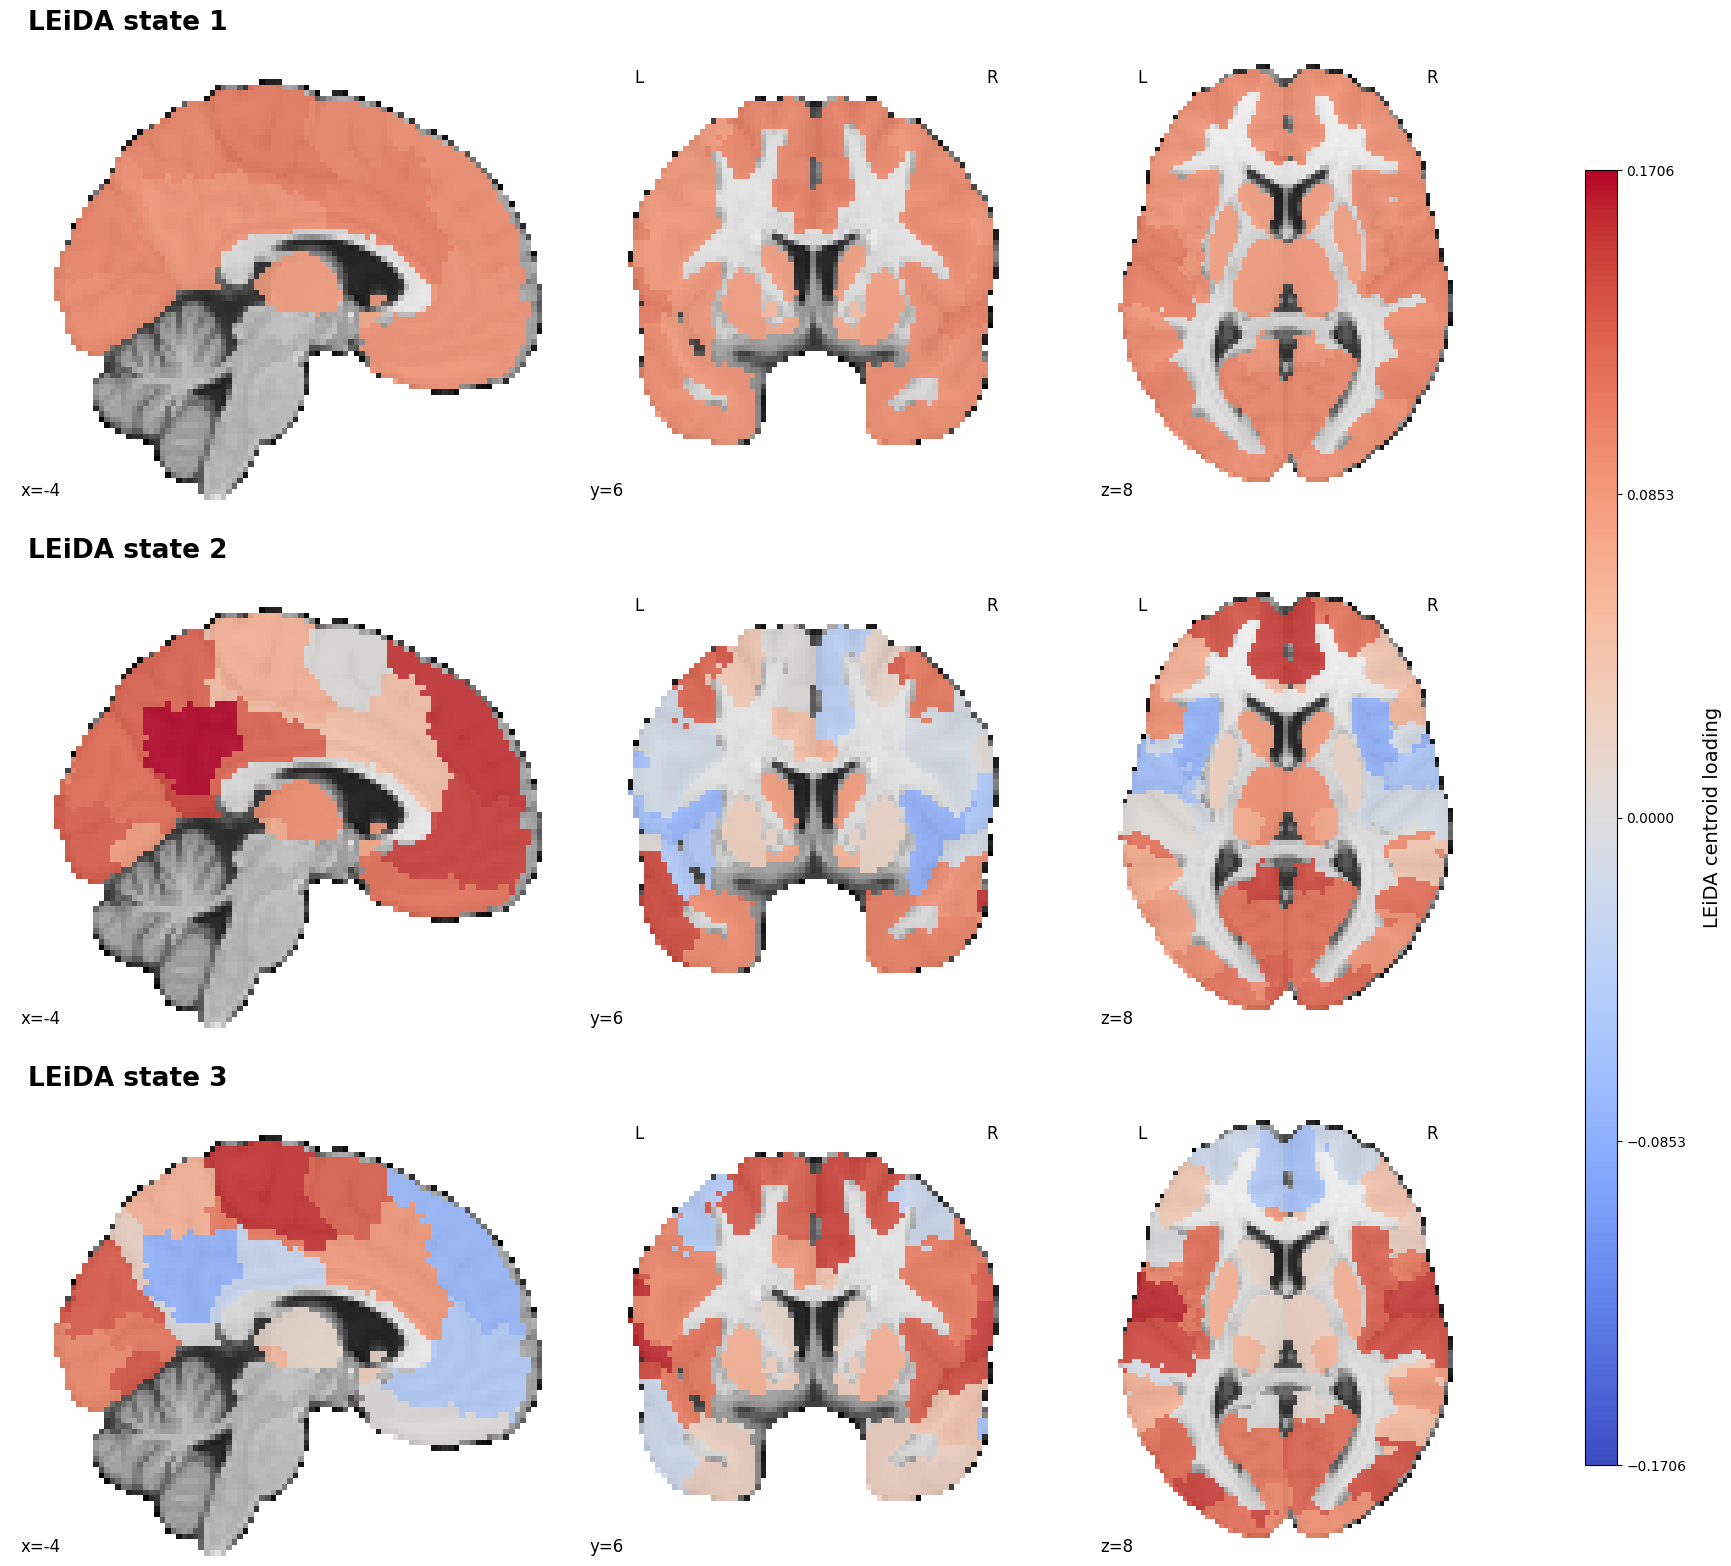

In [22]:
oriented_leida = leida_centroids.copy()
for centroid in oriented_leida:
    if centroid.sum() < 0 or (np.isclose(centroid.sum(), 0) and centroid[np.argmax(np.abs(centroid))] < 0):
        centroid *= -1

atlas_img = nib.load(str(ATLAS_FILE))
atlas_data = np.asarray(atlas_img.dataobj, dtype=np.int16)
atlas_header = atlas_img.header.copy()
atlas_header.set_data_dtype(np.float32)
background_img = resample_to_img(load_mni152_template(), atlas_img, interpolation="continuous")
brain_mask_img = resample_to_img(load_mni152_brain_mask(), atlas_img, interpolation="nearest")
brain_mask = np.asarray(brain_mask_img.dataobj) > 0.5
vmax = np.abs(oriented_leida).max()

fig = plt.figure(figsize=(17.5, 16.5), facecolor="white")
for state, (centroid, bottom) in enumerate(zip(oriented_leida, [0.690, 0.370, 0.050])):
    image_data = np.zeros(atlas_data.shape, dtype=np.float32)
    for atlas_label, value in enumerate(np.r_[centroid[100:], centroid[:100]], start=1):
        image_data[atlas_data == atlas_label] = value
    image_data[~brain_mask] = 0
    stat_img = nib.Nifti1Image(image_data, atlas_img.affine, atlas_header)
    ax = fig.add_axes([0.015, bottom, 0.865, 0.275])
    plotting.plot_stat_map(
        stat_img,
        bg_img=background_img,
        display_mode="ortho",
        cut_coords=(-4, 6, 8),
        draw_cross=False,
        annotate=True,
        black_bg=False,
        dim=-0.35,
        cmap="coolwarm",
        symmetric_cbar=True,
        vmin=-vmax,
        vmax=vmax,
        threshold=1e-8,
        transparency=0.88,
        colorbar=False,
        resampling_interpolation="nearest",
        figure=fig,
        axes=ax,
    )
    fig.text(0.025, bottom + 0.285, f"LEiDA state {state + 1}", fontsize=19, fontweight="semibold")

colorbar_ax = fig.add_axes([0.915, 0.105, 0.018, 0.785])
colorbar = fig.colorbar(ScalarMappable(norm=Normalize(-vmax, vmax), cmap="coolwarm"), cax=colorbar_ax)
colorbar.set_ticks(np.linspace(-vmax, vmax, 5))
colorbar.set_label("LEiDA centroid loading", fontsize=14, labelpad=12)
plt.show()


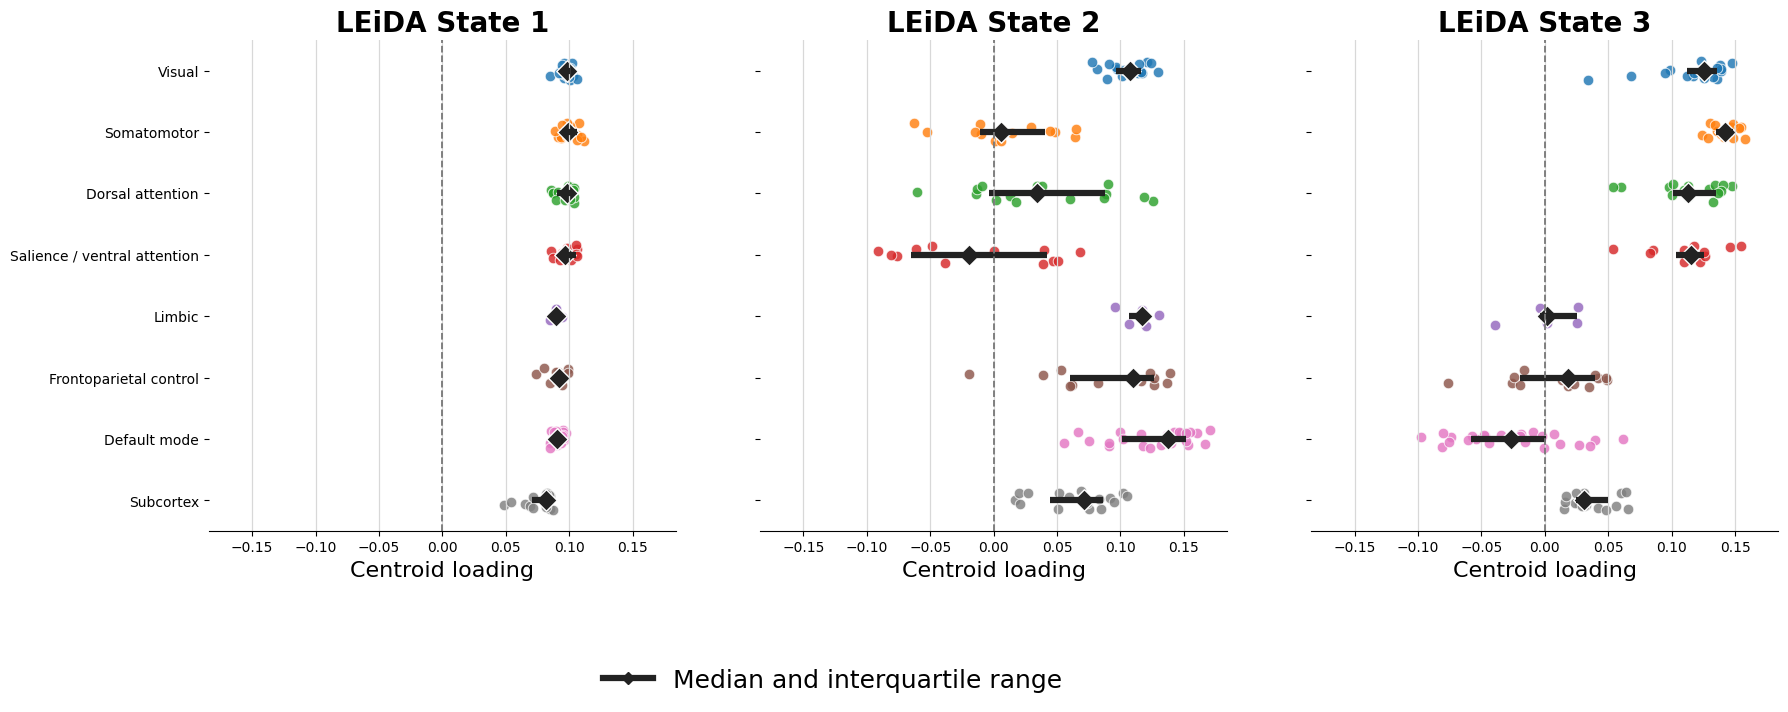

In [23]:
network_colours = {
    "Visual": "#1F77B4", "Somatomotor": "#FF7F0E", "Dorsal attention": "#2CA02C",
    "Salience / ventral attention": "#D62728", "Limbic": "#9467BD",
    "Control / frontoparietal": "#8C564B", "Default mode": "#E377C2", "Subcortex": "#7F7F7F",
}
network_display = {"Control / frontoparietal": "Frontoparietal control"}
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 3, figsize=(19.5, 7.8), sharex=True, sharey=True, facecolor="white")

for state, (ax, centroid) in enumerate(zip(axes, oriented_leida), start=1):
    for position, network in enumerate(NETWORK_ORDER):
        values = centroid[network_indices[network]]
        ax.scatter(
            values,
            position + rng.uniform(-0.16, 0.16, len(values)),
            s=58,
            color=network_colours[network],
            alpha=0.82,
            edgecolor="white",
            linewidth=0.65,
        )
        q25, median, q75 = np.quantile(values, [0.25, 0.5, 0.75])
        ax.hlines(position, q25, q75, color="#222222", linewidth=4.5)
        ax.scatter(median, position, marker="D", s=120, color="#222222", edgecolor="white")
    ax.axvline(0, color="#777777", linestyle="--", linewidth=1.3)
    ax.set_xlim(-1.08 * np.abs(oriented_leida).max(), 1.08 * np.abs(oriented_leida).max())
    ax.set_yticks(np.arange(len(NETWORK_ORDER)), labels=[network_display.get(x, x) for x in NETWORK_ORDER])
    ax.set_xlabel("Centroid loading", fontsize=16)
    ax.set_title(f"LEiDA State {state}", fontsize=20, fontweight="semibold")
    ax.grid(axis="x", color="#D8D8D8", linewidth=0.9)
    ax.spines[["top", "right", "left"]].set_visible(False)
axes[0].set_ylim(len(NETWORK_ORDER) - 0.5, -0.5)
for ax in axes[1:]:
    ax.tick_params(axis="y", labelleft=False)
fig.legend(
    handles=[Line2D([0], [0], color="#222222", linewidth=4.5, marker="D", label="Median and interquartile range")],
    loc="lower center", bbox_to_anchor=(0.5, 0.035), fontsize=18, frameon=False,
)
fig.subplots_adjust(left=0.18, right=0.985, bottom=0.27, top=0.90, wspace=0.18)
plt.show()


## EiDA centroid matrices and chord diagrams


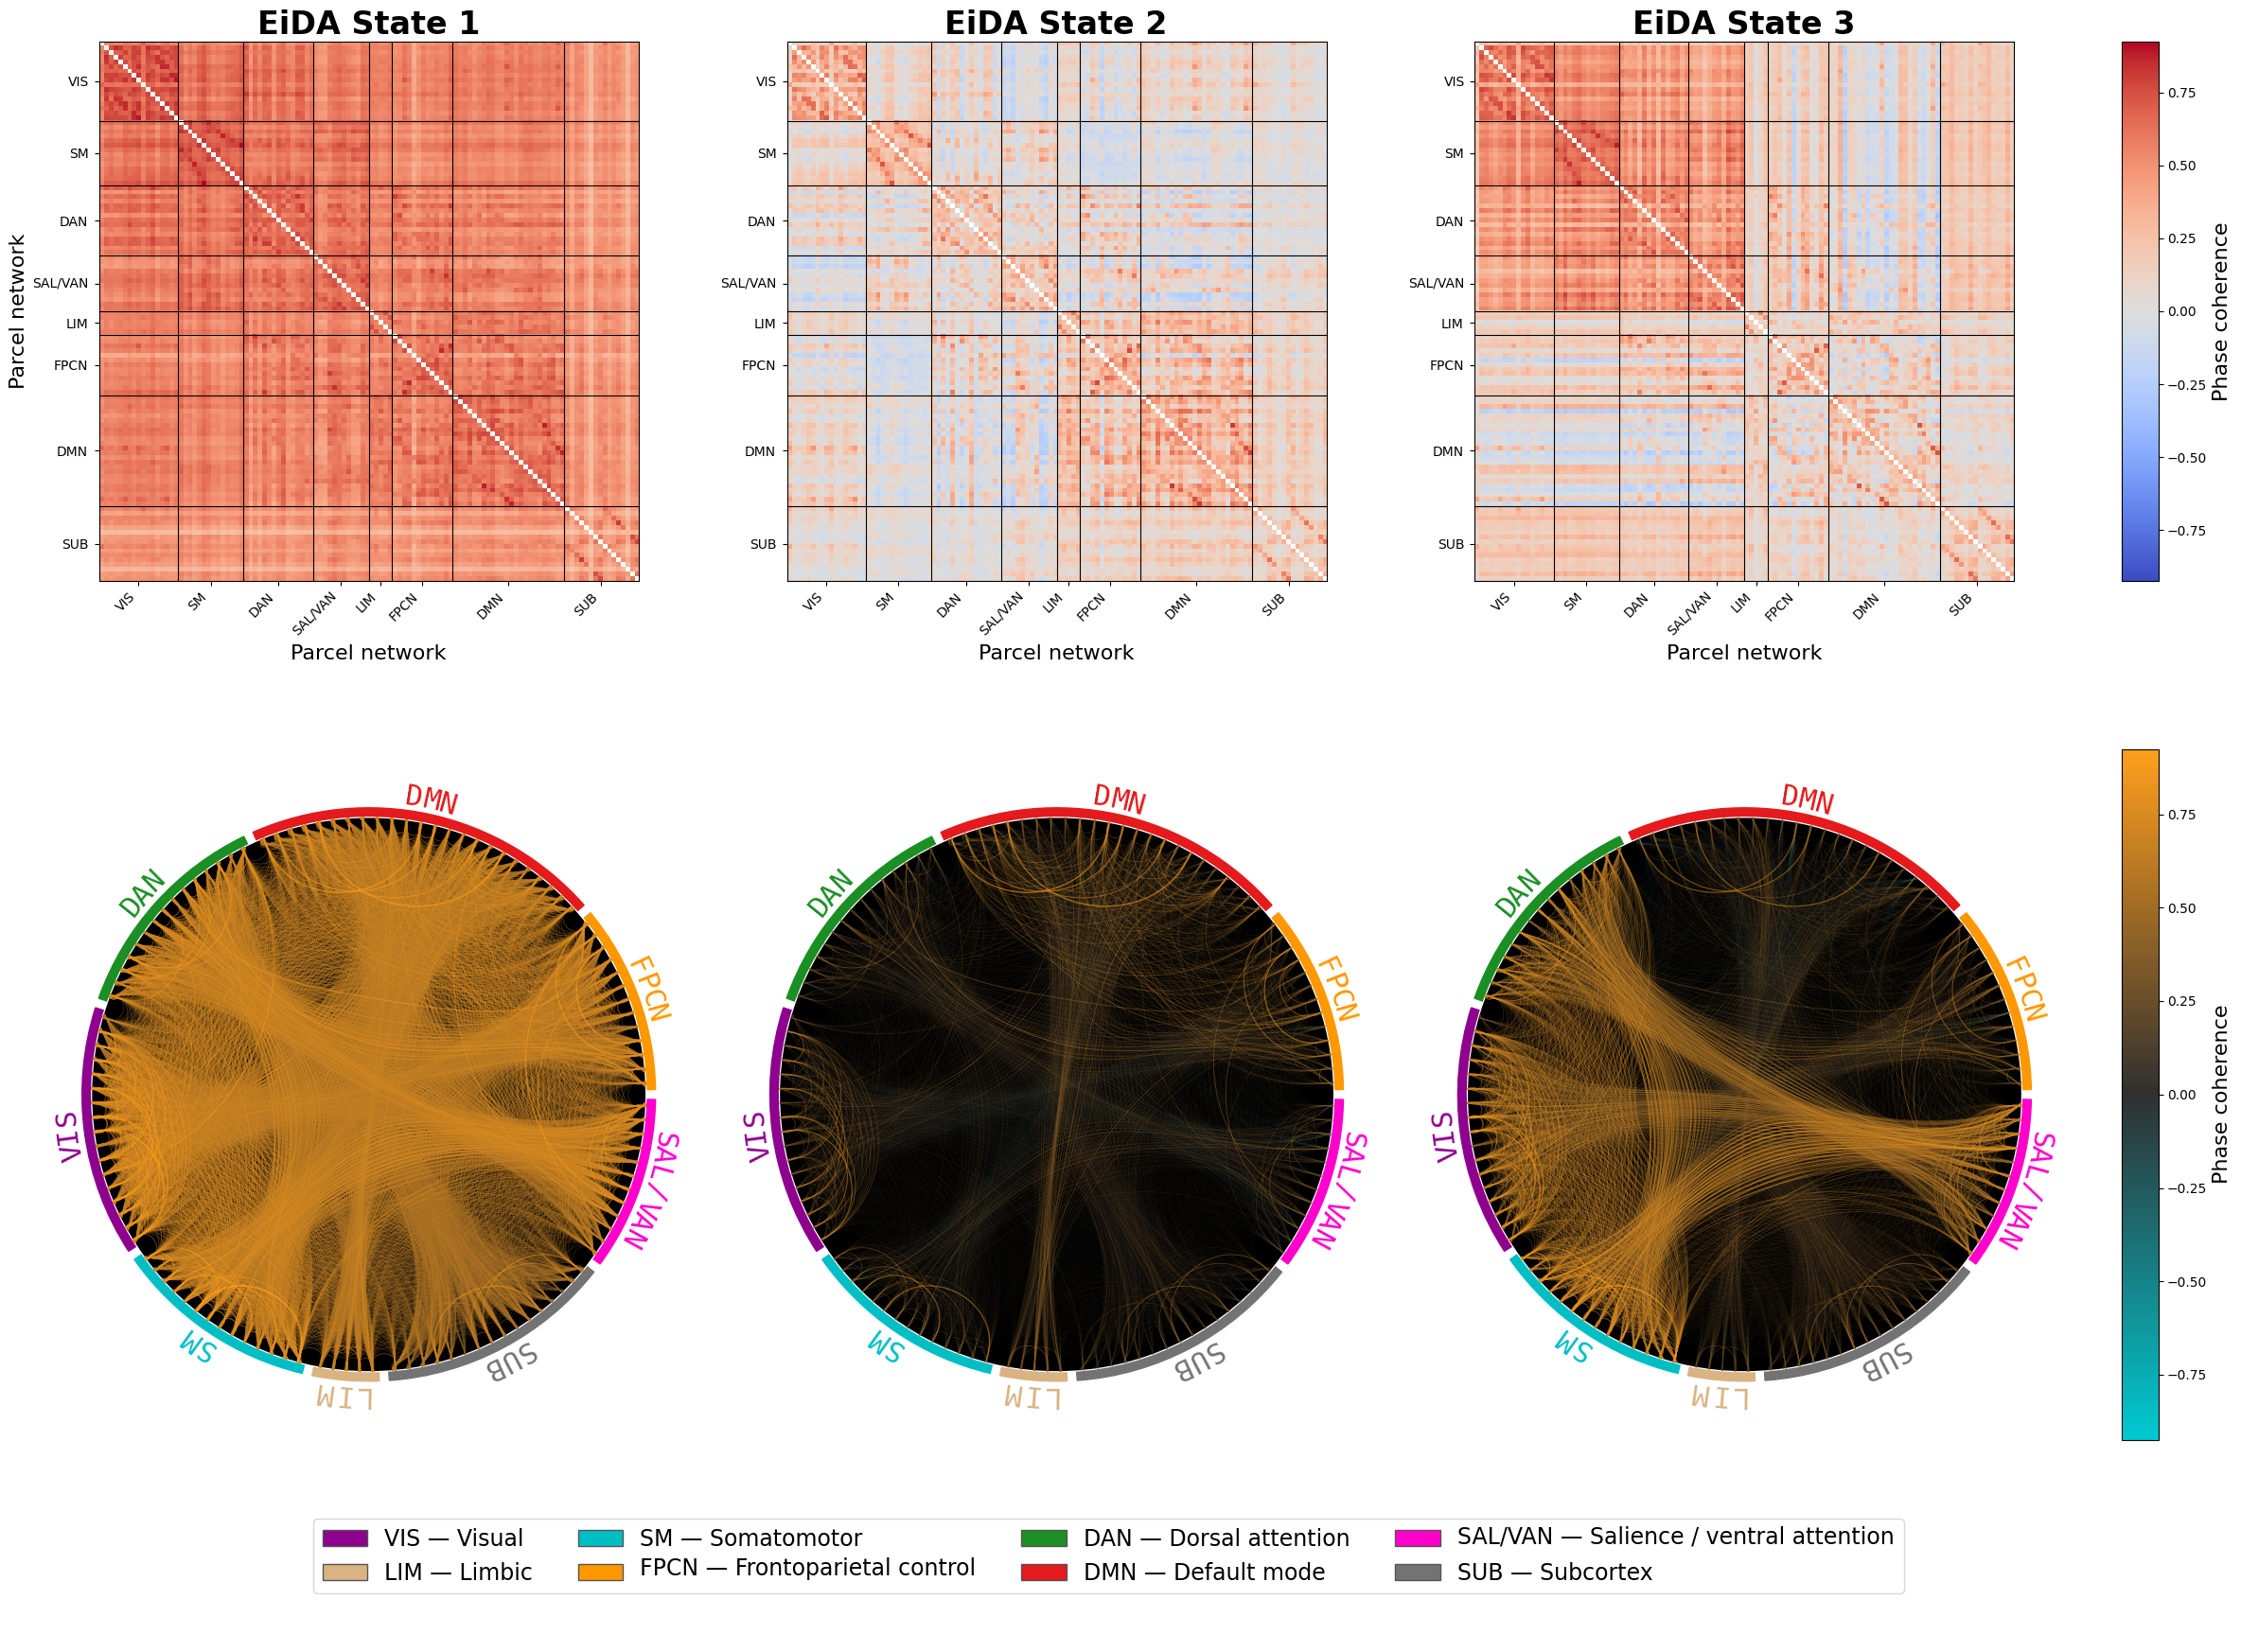

In [24]:
parcel_order = np.concatenate([network_indices[network] for network in NETWORK_ORDER])
network_sizes = np.array([len(network_indices[network]) for network in NETWORK_ORDER])
network_boundaries = np.cumsum(network_sizes)
network_centres = np.r_[0, network_boundaries[:-1]] + (network_sizes - 1) / 2
idx_to_label = {
    int(parcel): short
    for network, short in zip(NETWORK_ORDER, NETWORK_SHORT_NAMES)
    for parcel in network_indices[network]
}
chord_order = ["FPCN", "DMN", "DAN", "VIS", "SM", "LIM", "SUB", "SAL/VAN"]
chord_colours = {
    "DMN": "#E41A1C", "FPCN": "#FF9800", "SAL/VAN": "#FF00CC", "SUB": "#737373",
    "LIM": "#D9B382", "SM": "#00BFC4", "VIS": "#8E008E", "DAN": "#1B8E24",
}
network_full = dict(zip(NETWORK_SHORT_NAMES, [
    "Visual", "Somatomotor", "Dorsal attention", "Salience / ventral attention",
    "Limbic", "Frontoparietal control", "Default mode", "Subcortex",
]))
edge_row, edge_col = np.triu_indices(n_parcels, k=1)
edges = list(zip(edge_row.tolist(), edge_col.tolist()))
global_max = np.abs(eida_centroid_matrices[:, edge_row, edge_col]).max()
phase_cmap = LinearSegmentedColormap.from_list("phase", ["#00C9D2", "#303030", "#FF9F1C"])
coords = np.column_stack([np.zeros(n_parcels), np.arange(n_parcels), np.zeros(n_parcels)])

fig = plt.figure(figsize=(24, 18), facecolor="white")
grid = fig.add_gridspec(
    4, 4,
    width_ratios=[1, 1, 1, 0.06],
    height_ratios=[1, 0.20, 1.28, 0.32],
    left=0.04, right=0.965, bottom=0.035, top=0.975,
    wspace=0.14, hspace=0.08,
)
matrix_axes = [fig.add_subplot(grid[0, column]) for column in range(3)]
chord_axes = [fig.add_subplot(grid[2, column]) for column in range(3)]

for state, (ax, original_matrix) in enumerate(zip(matrix_axes, eida_centroid_matrices), start=1):
    matrix = original_matrix[np.ix_(parcel_order, parcel_order)].copy()
    np.fill_diagonal(matrix, np.nan)
    cmap = plt.colormaps["coolwarm"].copy()
    cmap.set_bad("white")
    ax.imshow(matrix, cmap=cmap, vmin=-global_max, vmax=global_max)
    for boundary in network_boundaries[:-1]:
        ax.axhline(boundary - 0.5, color="black", linewidth=0.8)
        ax.axvline(boundary - 0.5, color="black", linewidth=0.8)
    ax.set_xticks(network_centres, labels=NETWORK_SHORT_NAMES, rotation=45, ha="right")
    ax.set_yticks(network_centres, labels=NETWORK_SHORT_NAMES)
    ax.set_title(f"EiDA State {state}", fontsize=24, fontweight="semibold")
    ax.set_xlabel("Parcel network", fontsize=16)
    if state == 1:
        ax.set_ylabel("Parcel network", fontsize=16)

matrix_colorbar = fig.colorbar(
    ScalarMappable(norm=Normalize(-global_max, global_max), cmap="coolwarm"),
    cax=fig.add_subplot(grid[0, 3]),
)
matrix_colorbar.set_label("Phase coherence", fontsize=16)

for ax, matrix in zip(chord_axes, eida_centroid_matrices):
    weights = matrix[edge_row, edge_col]
    order = np.argsort(np.abs(weights))
    strength = np.abs(weights[order]) / global_max
    plt.sca(ax)
    with patch.object(plt, "figure", return_value=fig), patch.object(plt, "tight_layout", return_value=None):
        plot_chord(
            idx_to_label=idx_to_label,
            edges=[edges[index] for index in order],
            edge_weights=weights[order].tolist(),
            network_order=chord_order,
            network_colors=chord_colours,
            coords=coords,
            cmap=phase_cmap,
            vmin=-global_max,
            vmax=global_max,
            linewidths=(0.1 + 1.25 * strength**2).tolist(),
            alphas=(0.17 + 0.55 * strength**1.5).tolist(),
            black_BG=True,
            arc_setting=True,
            do_ROI_circles=False,
            label_fontsize=22,
            cbar=lambda: None,
            fp_chord=None,
        )
    ax.set_axis_off()

chord_colorbar = fig.colorbar(
    ScalarMappable(norm=Normalize(-global_max, global_max), cmap=phase_cmap),
    cax=fig.add_subplot(grid[2, 3]),
)
chord_colorbar.set_label("Phase coherence", fontsize=16)

legend_ax = fig.add_subplot(grid[3, :])
legend_ax.axis("off")
legend_handles = [
        mpatches.Patch(facecolor=chord_colours[short], edgecolor="#555555", label=f"{short} — {network_full[short]}")
        for short in NETWORK_SHORT_NAMES
    ]
legend_ax.legend(
    handles=[legend_handles[index] for index in [0, 4, 1, 5, 2, 6, 3, 7]],
    loc="center", ncol=4, fontsize=17, frameon=True,
)
plt.show()


## Information retained by LEiDA


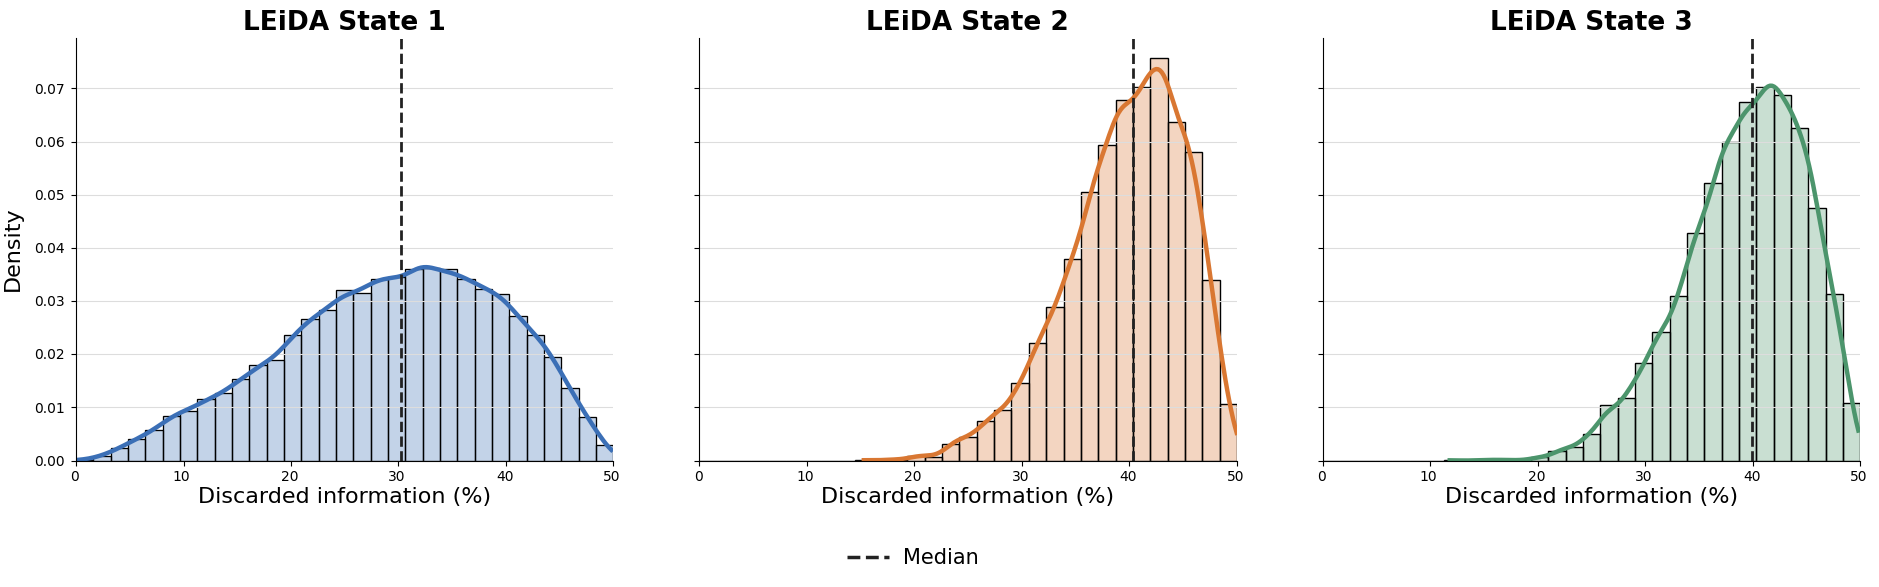

In [25]:
discarded_information = 100 * lambda2 / (lambda1 + lambda2)
discarded = time_info[["scan_ids", "subjects", "sessions", "treatment"]].copy()
discarded["state"] = leida_labels + 1
discarded["discarded_percent"] = discarded_information
discarded["state_label"] = discarded["state"].map(lambda state: f"LEiDA State {state}")
state_labels = [f"LEiDA State {state}" for state in range(1, BEST_K + 1)]
state_colours = ["#3B6FB6", "#D97732", "#4C956C"]
discarded_upper = max(5, min(50, 5 * np.ceil(discarded["discarded_percent"].max() / 5)))

fig, axes = plt.subplots(1, BEST_K, figsize=(19.5, 6.5), sharex=True, sharey=True, facecolor="white")
for index, (ax, state_label, colour) in enumerate(zip(axes, state_labels, state_colours)):
    values = discarded.loc[discarded["state_label"] == state_label, "discarded_percent"]
    sns.histplot(values, bins=np.linspace(0, discarded_upper, 32), stat="density", color=colour, alpha=0.30, ax=ax)
    sns.kdeplot(values, color=colour, linewidth=3.2, cut=0, clip=(0, discarded_upper), bw_adjust=0.9, ax=ax)
    ax.axvline(np.median(values), color="#222222", linestyle="--", linewidth=2)
    ax.set_title(state_label, fontsize=19, fontweight="semibold")
    ax.set_xlabel("Discarded information (%)", fontsize=16)
    ax.set_ylabel("Density" if index == 0 else "", fontsize=16)
    ax.set_xlim(0, discarded_upper)
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
fig.legend(
    handles=[Line2D([0], [0], color="#222222", linestyle="--", linewidth=2.5, label="Median")],
    loc="lower center", bbox_to_anchor=(0.5, 0.035), fontsize=15, frameon=False,
)
fig.subplots_adjust(left=0.07, right=0.985, bottom=0.23, top=0.88, wspace=0.16)
plt.show()


## LEiDA–EiDA agreement


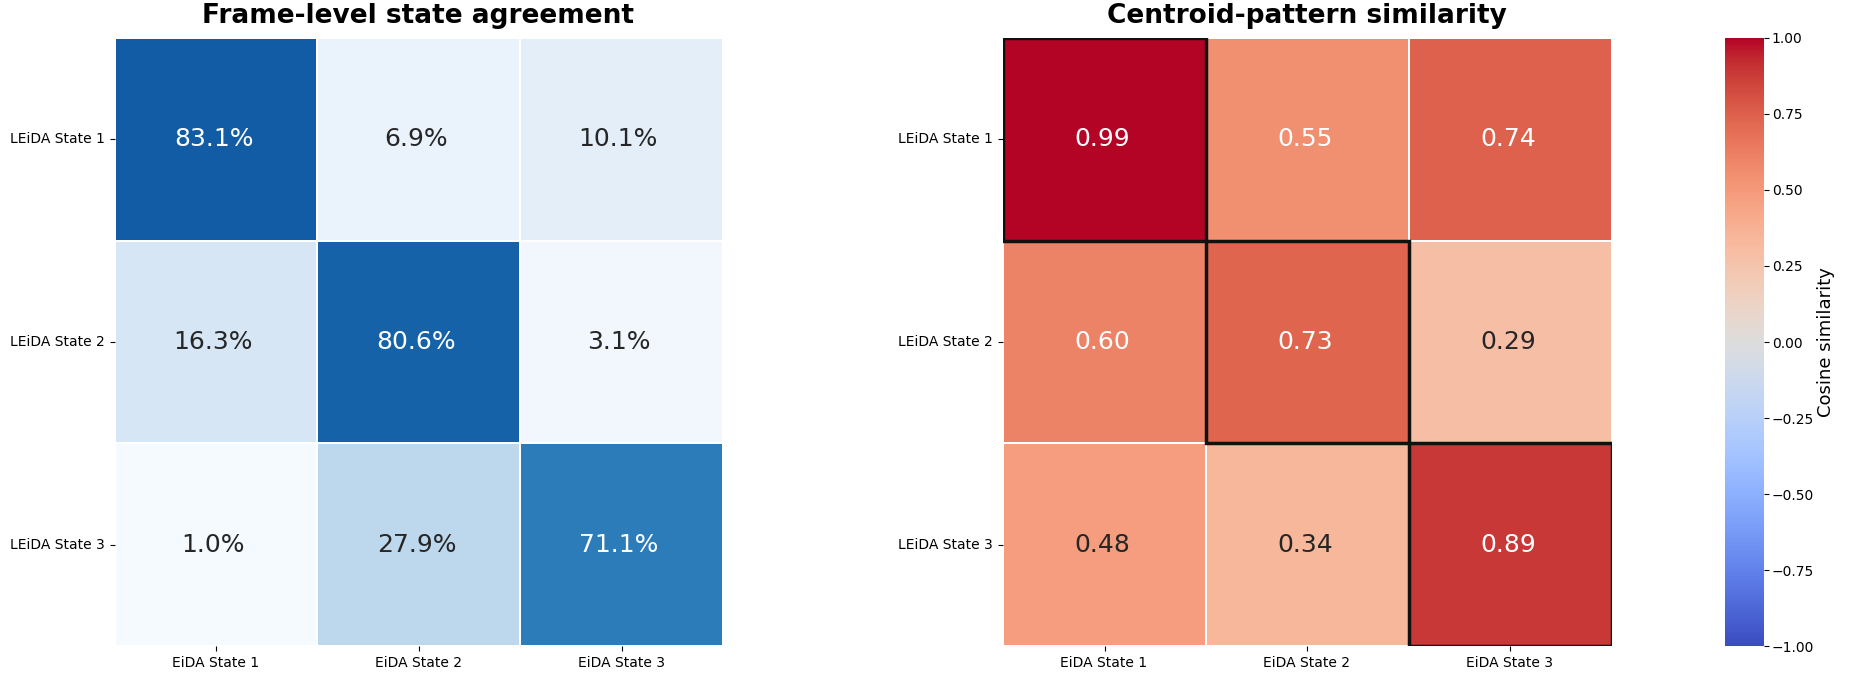

In [36]:
agreement_counts = confusion_matrix(leida_labels, eida_labels, labels=np.arange(BEST_K))
agreement_matrix = agreement_counts / agreement_counts.sum(axis=1, keepdims=True)

edge_i, edge_j = np.triu_indices(n_parcels, k=1)
leida_centroid_matrices = np.stack([np.outer(centroid, centroid) for centroid in leida_centroids])
centroid_similarity = cosine_similarity(
    leida_centroid_matrices[:, edge_i, edge_j],
    eida_centroid_matrices[:, edge_i, edge_j],
)
leida_match, eida_match = linear_sum_assignment(-centroid_similarity)

fig = plt.figure(figsize=(18.5, 7.8), facecolor="white")
outer = fig.add_gridspec(1, 2, width_ratios=[1, 1.12], left=0.04, right=0.97, bottom=0.12, top=0.90, wspace=0.16)
agreement_ax = fig.add_subplot(outer[0, 0])
right = outer[0, 1].subgridspec(1, 2, width_ratios=[1, 0.05], wspace=0.08)
similarity_ax = fig.add_subplot(right[0, 0])
colorbar_ax = fig.add_subplot(right[0, 1])

sns.heatmap(
    agreement_matrix,
    vmin=0, vmax=1, cmap="Blues", square=True, annot=True, fmt=".1%",
    annot_kws={"fontsize": 18},
    linewidths=1.2, linecolor="white", cbar=False, ax=agreement_ax,
)
agreement_ax.set_xticks(np.arange(BEST_K) + 0.5, labels=[f"EiDA State {x}" for x in range(1, BEST_K + 1)])
agreement_ax.set_yticks(np.arange(BEST_K) + 0.5, labels=[f"LEiDA State {x}" for x in range(1, BEST_K + 1)], rotation=0)
agreement_ax.set_title("Frame-level state agreement", fontsize=19, fontweight="semibold")

sns.heatmap(
    centroid_similarity,
    vmin=-1, vmax=1, center=0, cmap="coolwarm", square=True, annot=True, fmt=".2f",
    annot_kws={"fontsize": 18},
    linewidths=1.2, linecolor="white", cbar=True, cbar_ax=colorbar_ax, ax=similarity_ax,
)
for leida_state, eida_state in zip(leida_match, eida_match):
    similarity_ax.add_patch(Rectangle((eida_state, leida_state), 1, 1, fill=False, edgecolor="#111111", linewidth=2.5))
similarity_ax.set_xticks(np.arange(BEST_K) + 0.5, labels=[f"EiDA State {x}" for x in range(1, BEST_K + 1)])
similarity_ax.set_yticks(np.arange(BEST_K) + 0.5, labels=[f"LEiDA State {x}" for x in range(1, BEST_K + 1)], rotation=0)
similarity_ax.set_title("Centroid-pattern similarity", fontsize=19, fontweight="semibold")
colorbar_ax.set_ylabel("Cosine similarity", fontsize=13)
plt.show()


### Agreement as a function of retained information


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              agreement   No. Observations:                41280
Model:                          Logit   Df Residuals:                    41278
Method:                           MLE   Df Model:                            1
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                  0.1413
Time:                        05:54:53   Log-Likelihood:                -17433.
converged:                       True   LL-Null:                       -20301.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.4791      0.122    -53.284      0.000      -6.717      -6.241
R             12.3114      0.196     62.902      0.000      11.928      12.695
==============================================================================
"""

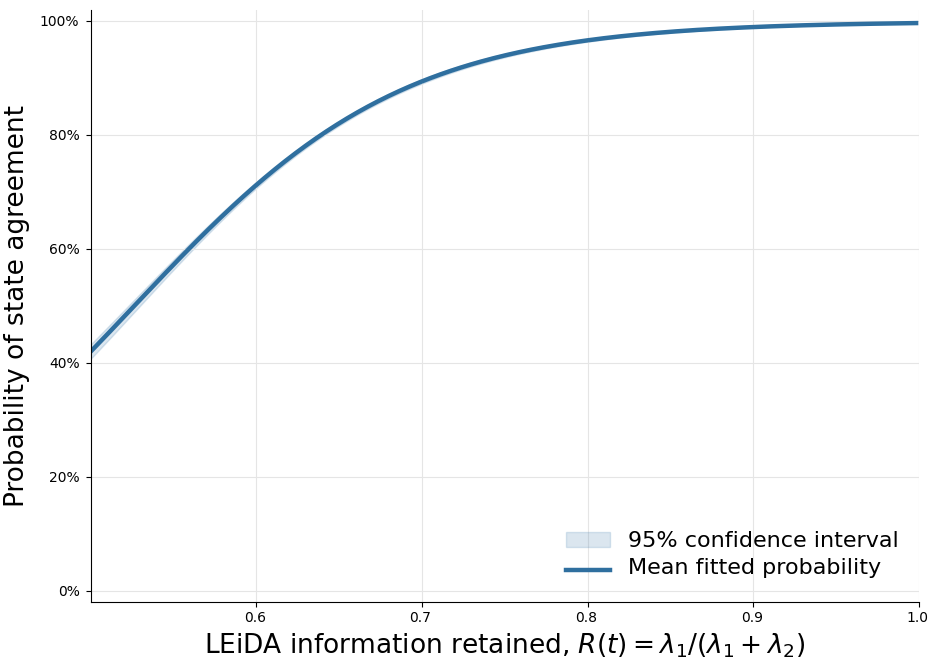

In [27]:
agreement_data = time_info[["subjects", "scan_ids", "frame"]].copy()
agreement_data["R"] = lambda1 / (lambda1 + lambda2)
agreement_data["agreement"] = (leida_labels == eida_labels).astype(int)

logistic_result = smf.logit("agreement ~ R", data=agreement_data).fit(disp=False)
display(logistic_result.summary())

r_grid = np.linspace(agreement_data["R"].min(), agreement_data["R"].max(), 400)
design = np.column_stack([np.ones_like(r_grid), r_grid])
coefficients = logistic_result.params.loc[["Intercept", "R"]].to_numpy()
covariance = logistic_result.cov_params().loc[["Intercept", "R"], ["Intercept", "R"]].to_numpy()
linear_prediction = design @ coefficients
linear_se = np.sqrt(np.einsum("ij,jk,ik->i", design, covariance, design))

fig, ax = plt.subplots(figsize=(9.5, 6.8), facecolor="white")
ax.fill_between(
    r_grid,
    expit(linear_prediction - 1.96 * linear_se),
    expit(linear_prediction + 1.96 * linear_se),
    color="#4C84B1", alpha=0.20, label="95% confidence interval",
)
ax.plot(r_grid, expit(linear_prediction), color="#2F6F9F", linewidth=3.2, label="Mean fitted probability")
ax.set_xlabel(r"LEiDA information retained, $R(t)=\lambda_1/(\lambda_1+\lambda_2)$", fontsize=19)
ax.set_ylabel("Probability of state agreement", fontsize=19)
ax.set_xlim(max(0.5, agreement_data["R"].min()), 1)
ax.set_ylim(-0.02, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(color="#E5E5E5", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", fontsize=16, frameon=False)
fig.tight_layout()
plt.show()


## State-dynamics inference


In [28]:
def get_pairs(method, metric, treatment, state, group):
    return (
        state_dynamics.loc[
            (state_dynamics["method"] == method)
            & (state_dynamics["treatment"] == treatment)
            & (state_dynamics["state"] == state)
            & (state_dynamics["response_status"] == group),
            ["subjects", "timepoints", metric],
        ]
        .pivot_table(index="subjects", columns="timepoints", values=metric, aggfunc="first")
        .reindex(columns=["pre", "post"])
        .dropna()
        .sort_index()
    )


def find_permutation_bounds(p_value, estimate, step):
    bounds = []
    for direction in [-1, 1]:
        inside = estimate
        outside = estimate + direction * step
        while p_value(outside) >= 0.05:
            outside = estimate + 2 * (outside - estimate)
        for _ in range(50):
            midpoint = (inside + outside) / 2
            if p_value(midpoint) >= 0.05:
                inside = midpoint
            else:
                outside = midpoint
        bounds.append(inside)
    return bounds


def paired_permutation_inference(changes, seed):
    changes = np.asarray(changes, dtype=float)
    n = len(changes)
    rng = np.random.default_rng(seed)
    signs = rng.choice([-1, 1], size=(N_PERMUTATIONS, n))
    signed_sums = signs @ changes
    sign_sums = signs.sum(axis=1)
    estimate = changes.mean()
    tolerance = 100 * np.finfo(float).eps * max(1, np.abs(changes).max())

    def p_value(null):
        observed = abs(estimate - null)
        permuted = np.abs((signed_sums - null * sign_sums) / n)
        return (np.count_nonzero(permuted >= observed - tolerance) + 1) / (N_PERMUTATIONS + 1)

    bounds = find_permutation_bounds(
        p_value,
        estimate,
        max(changes.std(ddof=1), np.ptp(changes), abs(estimate), 1e-6),
    )
    correction = 1 - 3 / (4 * (n - 1) - 1)
    hedges_gz = correction * estimate / changes.std(ddof=1)
    return estimate, bounds[0], bounds[1], p_value(0), hedges_gz


def independent_permutation_inference(responder, non_responder, seed):
    responder = np.asarray(responder, dtype=float)
    non_responder = np.asarray(non_responder, dtype=float)
    n_responder = len(responder)
    n_non_responder = len(non_responder)
    combined = np.r_[responder, non_responder]
    rng = np.random.default_rng(seed)
    random_values = rng.random((N_PERMUTATIONS, len(combined)))
    selected = np.argpartition(random_values, kth=n_responder - 1, axis=1)[:, :n_responder]
    selected_sums = combined[selected].sum(axis=1)
    base_statistics = (
        selected_sums / n_responder
        - (combined.sum() - selected_sums) / n_non_responder
    )
    original_responders_selected = (selected < n_responder).sum(axis=1)
    slopes = (
        -original_responders_selected / n_responder
        + (n_responder - original_responders_selected) / n_non_responder
    )
    estimate = responder.mean() - non_responder.mean()
    tolerance = 100 * np.finfo(float).eps * max(1, np.abs(combined).max())

    def p_value(null):
        observed = abs(estimate - null)
        permuted = np.abs(base_statistics + null * slopes)
        return (np.count_nonzero(permuted >= observed - tolerance) + 1) / (N_PERMUTATIONS + 1)

    bounds = find_permutation_bounds(
        p_value,
        estimate,
        max(responder.std(ddof=1), non_responder.std(ddof=1), np.ptp(combined), abs(estimate), 1e-6),
    )
    degrees_of_freedom = n_responder + n_non_responder - 2
    pooled_sd = np.sqrt(
        ((n_responder - 1) * responder.var(ddof=1) + (n_non_responder - 1) * non_responder.var(ddof=1))
        / degrees_of_freedom
    )
    hedges_g = (1 - 3 / (4 * degrees_of_freedom - 1)) * estimate / pooled_sd
    return estimate, bounds[0], bounds[1], p_value(0), hedges_g


In [29]:
methods = ["LEiDA", "Discrete EiDA"]
metrics = ["dwell_time_seconds", "fractional_occupancy"]
treatments = ["escitalopram", "psilocybin"]
groups = ["responder", "non_responder"]
test_rows = []
seed = 88

for method in methods:
    for metric in metrics:
        for treatment in treatments:
            for state in range(1, BEST_K + 1):
                changes_by_group = {}
                for group in groups:
                    paired = get_pairs(method, metric, treatment, state, group)
                    changes = (paired["post"] - paired["pre"]).to_numpy()
                    changes_by_group[group] = changes
                    estimate, ci_low, ci_high, p_value, effect = paired_permutation_inference(changes, seed)
                    seed += 1
                    test_rows.append({
                        "method": method,
                        "metric": metric,
                        "treatment": treatment,
                        "state": state,
                        "comparison": f"{group}: pre vs post",
                        "group": group,
                        "n": len(paired),
                        "pre_mean": paired["pre"].mean(),
                        "post_mean": paired["post"].mean(),
                        "estimate": estimate,
                        "ci_low": ci_low,
                        "ci_high": ci_high,
                        "effect_size": effect,
                        "p_value": p_value,
                    })

                responder = changes_by_group["responder"]
                non_responder = changes_by_group["non_responder"]
                estimate, ci_low, ci_high, p_value, effect = independent_permutation_inference(
                    responder, non_responder, seed
                )
                seed += 1
                test_rows.append({
                    "method": method,
                    "metric": metric,
                    "treatment": treatment,
                    "state": state,
                    "comparison": "responder vs non_responder difference in change",
                    "group": np.nan,
                    "n": len(responder) + len(non_responder),
                    "n_responder": len(responder),
                    "n_non_responder": len(non_responder),
                    "responder_mean_change": responder.mean(),
                    "non_responder_mean_change": non_responder.mean(),
                    "estimate": estimate,
                    "ci_low": ci_low,
                    "ci_high": ci_high,
                    "effect_size": effect,
                    "p_value": p_value,
                })

state_tests = pd.DataFrame(test_rows)
state_tests["q_value"] = np.nan
for indices in state_tests.groupby(["method", "metric"]).groups.values():
    state_tests.loc[indices, "q_value"] = multipletests(
        state_tests.loc[indices, "p_value"], method="fdr_bh"
    )[1]


### Matched LEiDA/EiDA state-dynamics plots


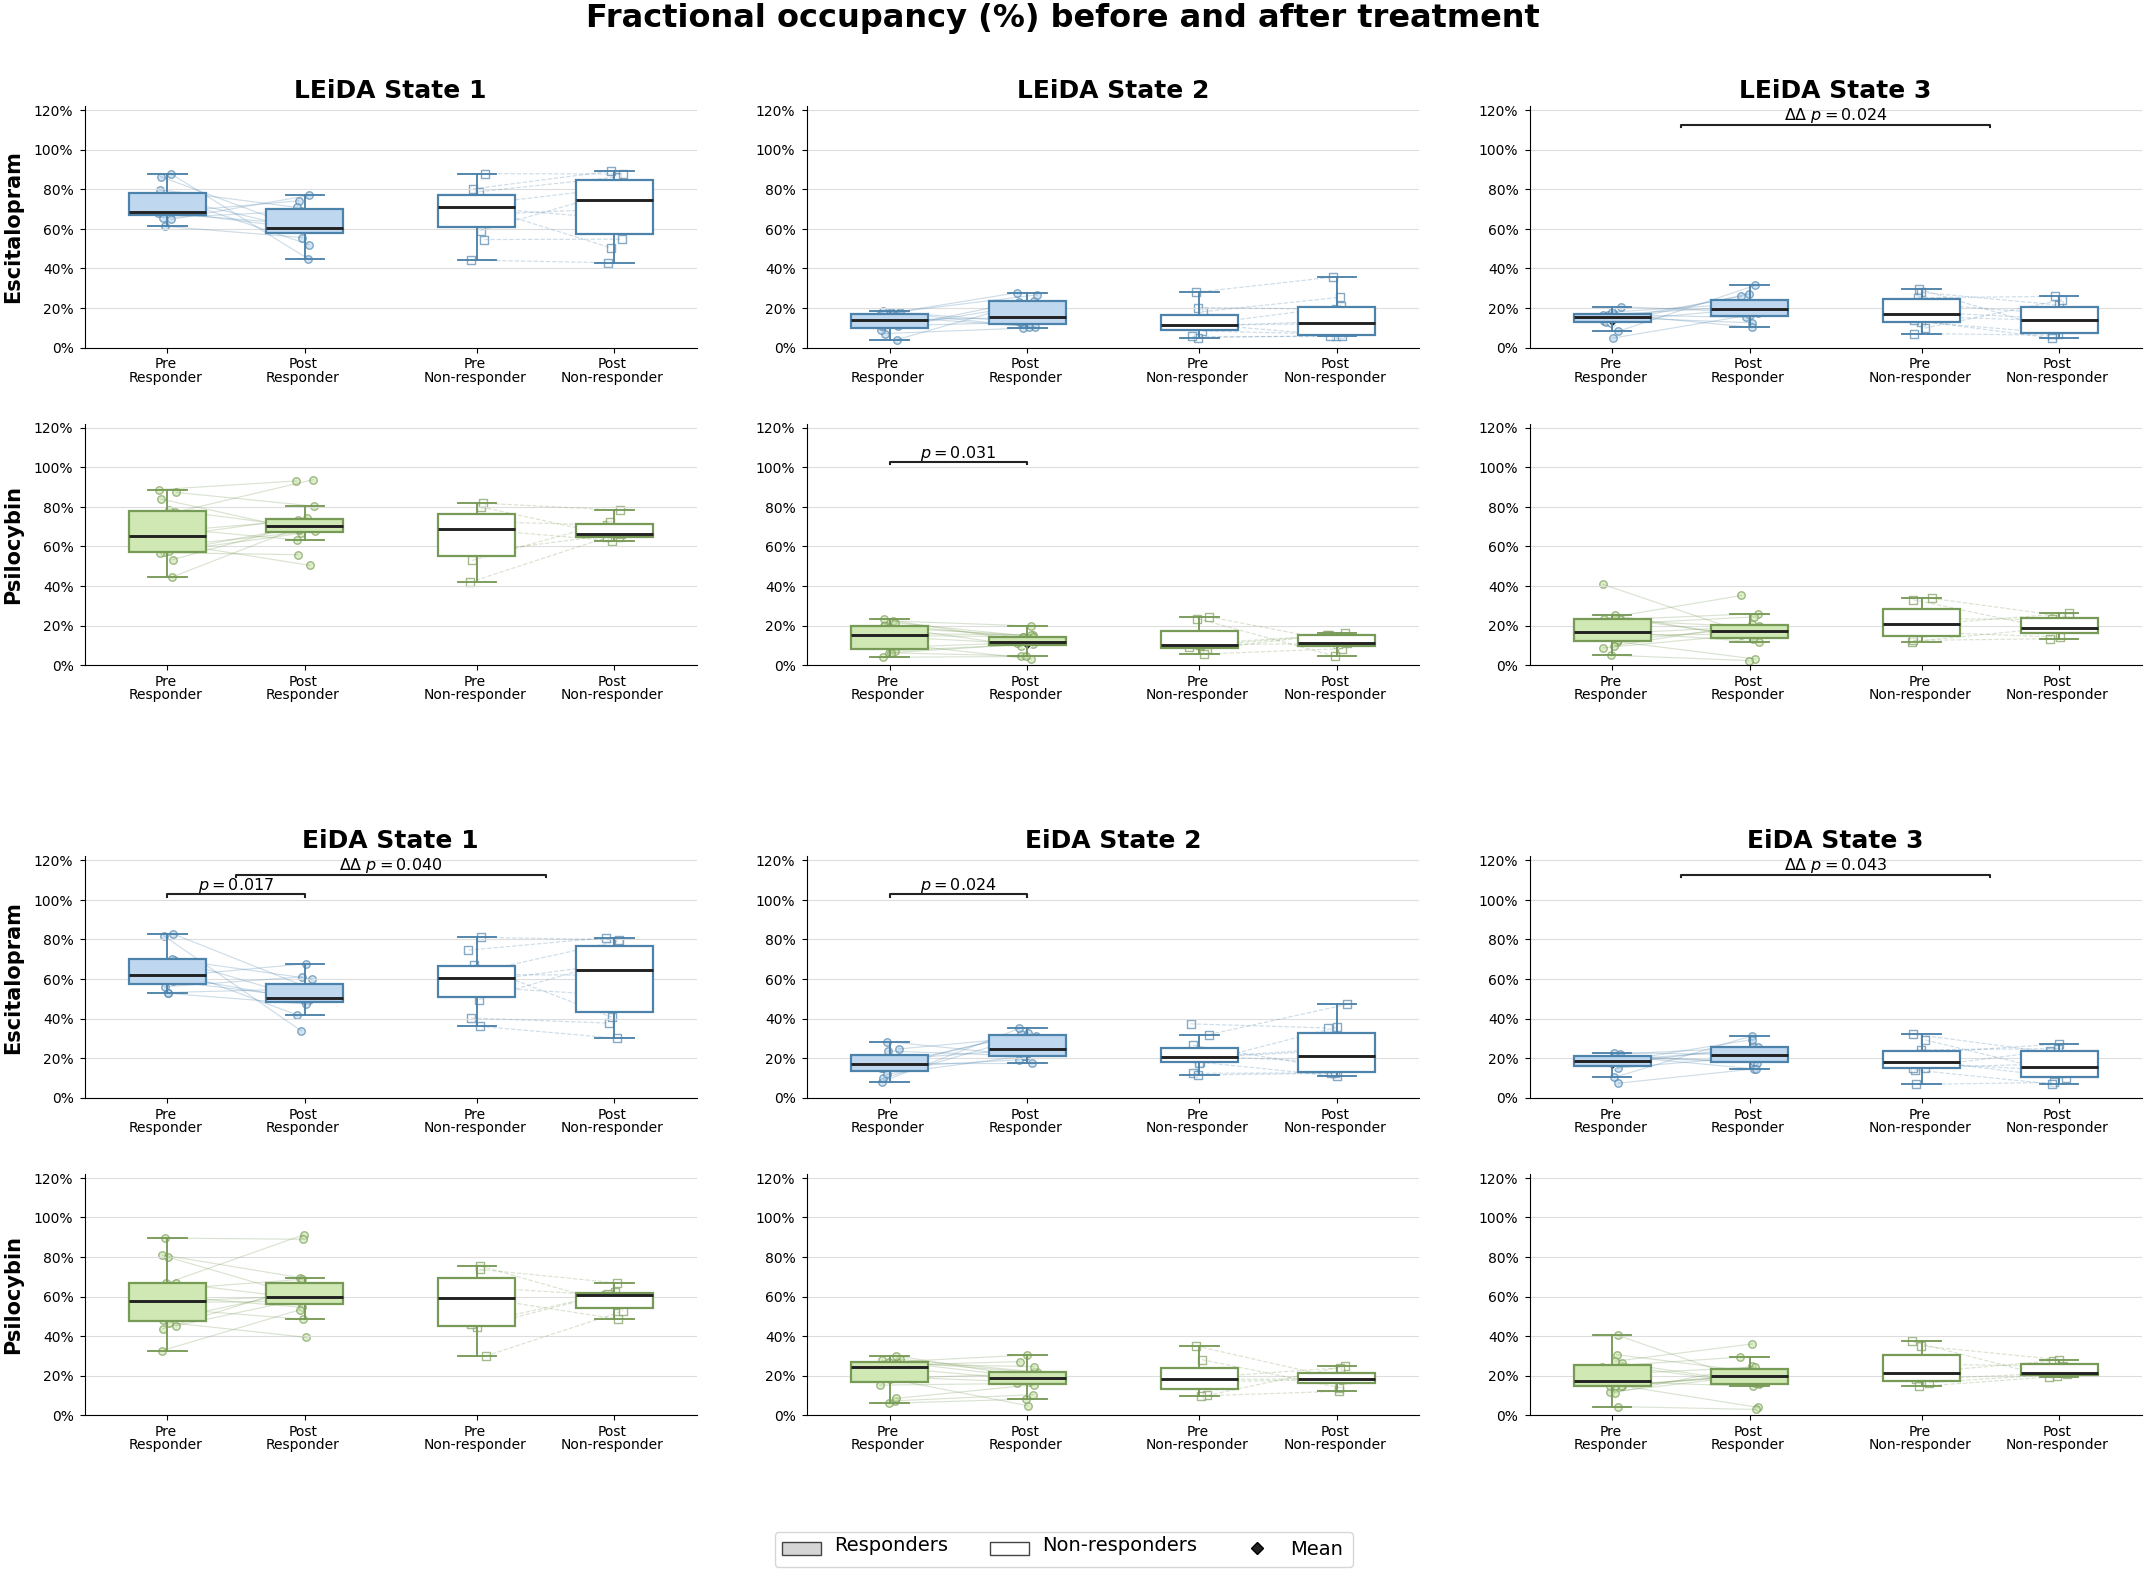

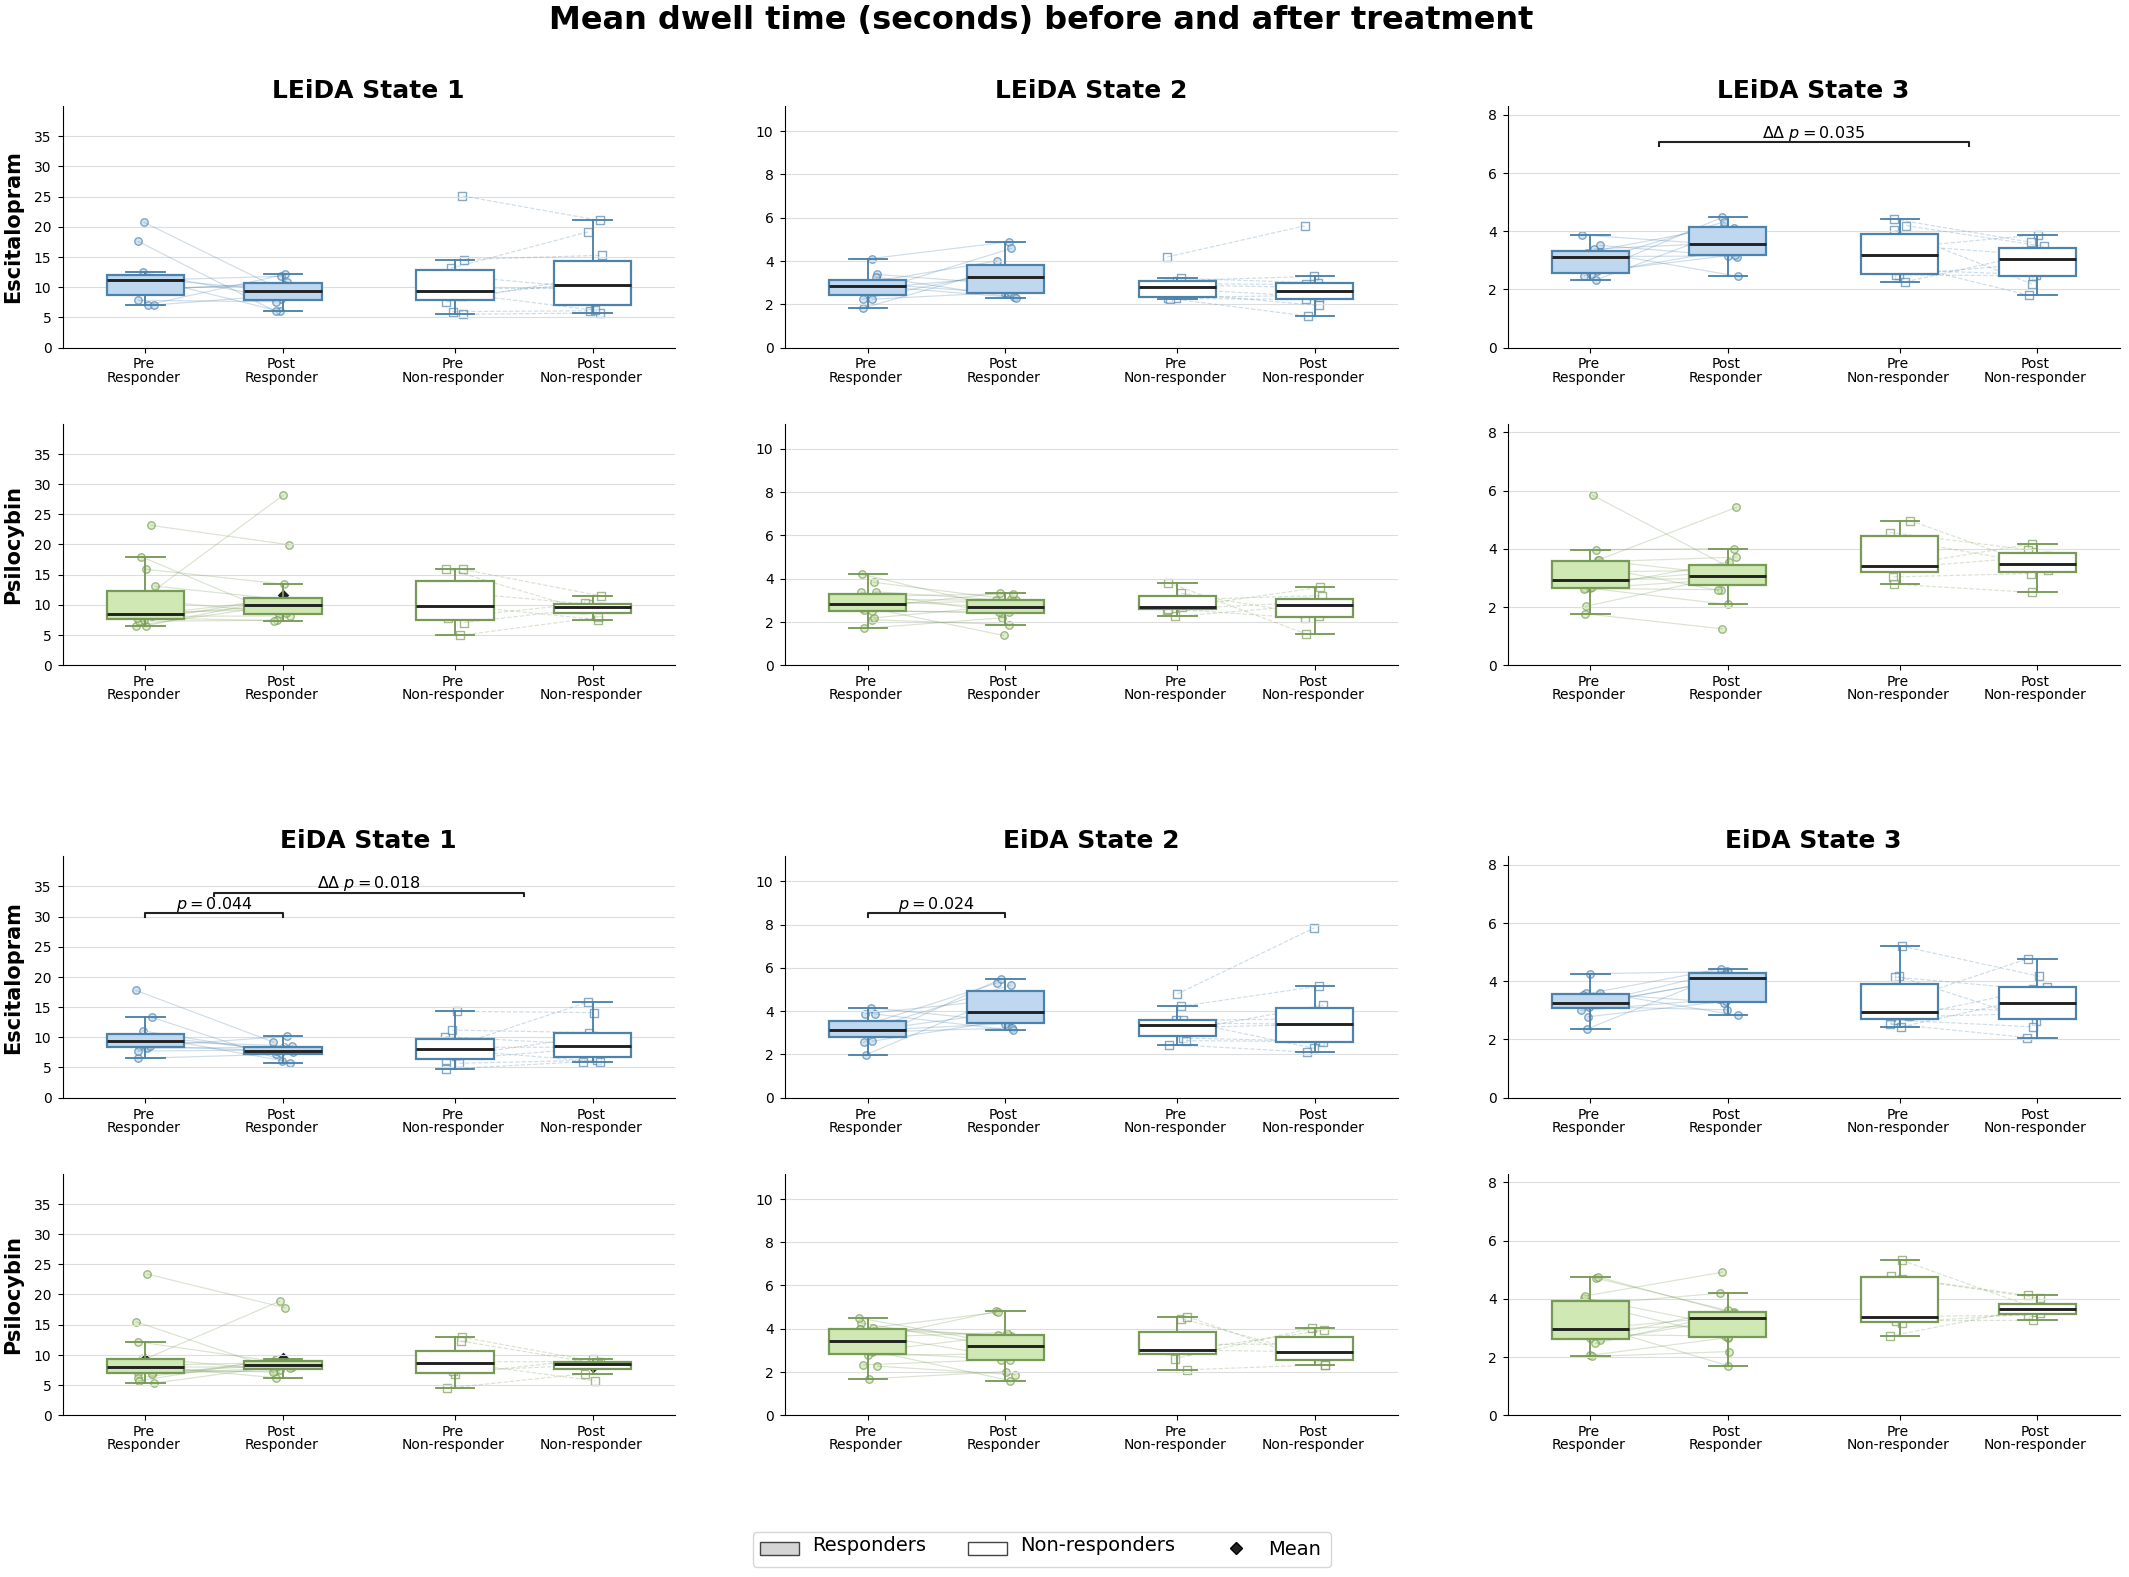

In [30]:
treatment_colours = {
    "escitalopram": {"light": "#BFD8F0", "dark": "#4D82AA"},
    "psilocybin": {"light": "#CFE8B4", "dark": "#789A57"},
}
row_layout = [
    ("LEiDA", "escitalopram"), ("LEiDA", "psilocybin"),
    ("Discrete EiDA", "escitalopram"), ("Discrete EiDA", "psilocybin"),
]
x_positions = {"responder": (0, 1), "non_responder": (2.25, 3.25)}
rng = np.random.default_rng(88)

for metric, title in [
    ("fractional_occupancy", "Fractional occupancy (%) before and after treatment"),
    ("dwell_time_seconds", "Mean dwell time (seconds) before and after treatment"),
]:
    fig = plt.figure(figsize=(22, 17), facecolor="white")
    grid = fig.add_gridspec(5, 3, height_ratios=[1, 1, 0.16, 1, 1], hspace=0.38, wspace=0.18)
    axes = np.array([
        [fig.add_subplot(grid[row, column]) for column in range(3)]
        for row in [0, 1, 3, 4]
    ])

    for row, (method, treatment) in enumerate(row_layout):
        colours = treatment_colours[treatment]
        for column, state in enumerate(range(1, BEST_K + 1)):
            ax = axes[row, column]
            selected_values = state_dynamics.loc[
                state_dynamics["state"] == state, metric
            ].dropna().to_numpy()
            if metric == "fractional_occupancy":
                bracket_base, bracket_step, bracket_height, ymax = 1.015, 0.10, 0.012, 1.22
            else:
                ceiling = 1.03 * selected_values.max()
                bracket_base, bracket_step = 1.035 * ceiling, 0.12 * ceiling
                bracket_height, ymax = 0.018 * ceiling, 1.38 * ceiling

            for group in groups:
                paired = get_pairs(method, metric, treatment, state, group)
                pre = paired["pre"].to_numpy()
                post = paired["post"].to_numpy()
                jitter = rng.uniform(-0.075, 0.075, len(paired))
                x_pre, x_post = x_positions[group]
                linestyle = "-" if group == "responder" else "--"
                marker = "o" if group == "responder" else "s"
                fill = colours["light"] if group == "responder" else "white"
                for participant in range(len(paired)):
                    ax.plot(
                        [x_pre + jitter[participant], x_post + jitter[participant]],
                        [pre[participant], post[participant]],
                        color=colours["dark"], linestyle=linestyle, linewidth=0.85, alpha=0.27,
                    )
                    ax.scatter(
                        [x_pre + jitter[participant], x_post + jitter[participant]],
                        [pre[participant], post[participant]],
                        marker=marker, s=29, facecolor=fill, edgecolor=colours["dark"], alpha=0.68,
                    )
                ax.boxplot(
                    [pre, post], positions=[x_pre, x_post], widths=0.56, patch_artist=True,
                    showfliers=False, manage_ticks=False,
                    boxprops={"facecolor": fill, "edgecolor": colours["dark"], "linewidth": 1.6},
                    medianprops={"color": "#222222", "linewidth": 2.1},
                    whiskerprops={"color": colours["dark"], "linewidth": 1.35},
                    capprops={"color": colours["dark"], "linewidth": 1.35},
                )
                ax.scatter([x_pre, x_post], [pre.mean(), post.mean()], marker="D", s=48, color="#222222", edgecolor="white")

                result = state_tests.loc[
                    (state_tests["method"] == method)
                    & (state_tests["metric"] == metric)
                    & (state_tests["treatment"] == treatment)
                    & (state_tests["state"] == state)
                    & (state_tests["comparison"] == f"{group}: pre vs post")
                ].iloc[0]
                if result["p_value"] <= 0.05:
                    label = r"$p < .001$" if result["p_value"] < 0.001 else rf"$p = {result['p_value']:.3f}$"
                    ax.plot([x_pre, x_pre, x_post, x_post], [bracket_base, bracket_base + bracket_height, bracket_base + bracket_height, bracket_base], color="#222222")
                    ax.text((x_pre + x_post) / 2, bracket_base + bracket_height, label, ha="center", va="bottom", fontsize=11.5)

            interaction = state_tests.loc[
                (state_tests["method"] == method)
                & (state_tests["metric"] == metric)
                & (state_tests["treatment"] == treatment)
                & (state_tests["state"] == state)
                & (state_tests["comparison"] == "responder vs non_responder difference in change")
            ].iloc[0]
            if interaction["p_value"] <= 0.05:
                label = r"$p < .001$" if interaction["p_value"] < 0.001 else rf"$p = {interaction['p_value']:.3f}$"
                y = bracket_base + bracket_step
                ax.plot([0.5, 0.5, 2.75, 2.75], [y, y + bracket_height, y + bracket_height, y], color="#222222")
                ax.text(1.625, y + bracket_height, r"$\Delta\Delta$ " + label, ha="center", va="bottom", fontsize=11.5)

            ax.set_xlim(-0.60, 3.85)
            ax.set_ylim(0, ymax)
            ax.set_xticks([0, 1, 2.25, 3.25], labels=["Pre\nResponder", "Post\nResponder", "Pre\nNon-responder", "Post\nNon-responder"])
            ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
            ax.spines[["top", "right"]].set_visible(False)
            if row in [0, 2]:
                ax.set_title(f"{'LEiDA' if method == 'LEiDA' else 'EiDA'} State {state}", fontsize=18, fontweight="semibold")
            if column == 0:
                ax.set_ylabel(treatment.capitalize(), fontsize=15, fontweight="semibold")
            if metric == "fractional_occupancy":
                ax.yaxis.set_major_formatter(PercentFormatter(1))

    fig.legend(
        handles=[
            Patch(facecolor="#D5D5D5", edgecolor="#444444", label="Responders"),
            Patch(facecolor="white", edgecolor="#444444", label="Non-responders"),
            Line2D([0], [0], color="none", marker="D", markerfacecolor="#222222", label="Mean"),
        ],
        loc="lower center", ncol=3, fontsize=14, bbox_to_anchor=(0.5, 0.060),
    )
    fig.suptitle(title, fontsize=23, fontweight="semibold", y=0.982)
    fig.subplots_adjust(left=0.055, right=0.990, top=0.925, bottom=0.155)
    plt.show()


### State-dynamics tables


In [31]:
def p_text(value):
    return "< .001" if value < 0.001 else f"{value:.3f}"


for metric, label, scale, decimals, unit in [
    ("fractional_occupancy", "Fractional occupancy", 100, 1, "percentage points"),
    ("dwell_time_seconds", "Dwell time", 1, 2, "s"),
]:
    within = state_tests.loc[
        (state_tests["metric"] == metric) & state_tests["group"].notna()
    ].copy()
    within_table = pd.DataFrame({
        "Method": within["method"].replace({"Discrete EiDA": "EiDA"}),
        "Treatment": within["treatment"].str.capitalize(),
        "State": within["state"],
        "Group": within["group"].replace({"responder": "Responder", "non_responder": "Non-responder"}),
        "n": within["n"],
        "Pre mean": (within["pre_mean"] * scale).round(decimals),
        "Post mean": (within["post_mean"] * scale).round(decimals),
        f"Mean change ({unit}) [95% inverted permutation CI]": [
            f"{estimate * scale:.{decimals}f} [{low * scale:.{decimals}f}, {high * scale:.{decimals}f}]"
            for estimate, low, high in zip(within["estimate"], within["ci_low"], within["ci_high"])
        ],
        "Hedges gₙ": within["effect_size"].map(lambda value: f"{value:.2f}"),
        "Raw p": within["p_value"].map(p_text),
        "BH q": within["q_value"].map(p_text),
        "BH significant": (within["q_value"] < 0.05).map({True: "Yes", False: "No"}),
    })

    difference = state_tests.loc[
        (state_tests["metric"] == metric) & state_tests["group"].isna()
    ].copy()
    difference_table = pd.DataFrame({
        "Method": difference["method"].replace({"Discrete EiDA": "EiDA"}),
        "Treatment": difference["treatment"].str.capitalize(),
        "State": difference["state"],
        "n responder": difference["n_responder"].astype(int),
        "n non-responder": difference["n_non_responder"].astype(int),
        f"Responder change ({unit})": (difference["responder_mean_change"] * scale).round(decimals),
        f"Non-responder change ({unit})": (difference["non_responder_mean_change"] * scale).round(decimals),
        f"Difference-in-change ({unit}) [95% inverted permutation CI]": [
            f"{estimate * scale:.{decimals}f} [{low * scale:.{decimals}f}, {high * scale:.{decimals}f}]"
            for estimate, low, high in zip(difference["estimate"], difference["ci_low"], difference["ci_high"])
        ],
        "Hedges g": difference["effect_size"].map(lambda value: f"{value:.2f}"),
        "Raw p": difference["p_value"].map(p_text),
        "BH q": difference["q_value"].map(p_text),
        "BH significant": (difference["q_value"] < 0.05).map({True: "Yes", False: "No"}),
    })

    display(Markdown(f"#### {label}: within-group pre–post changes"))
    display(within_table.reset_index(drop=True))
    display(Markdown(f"#### {label}: responder–non-responder differences in change"))
    display(difference_table.reset_index(drop=True))


#### Fractional occupancy: within-group pre–post changes

,Method,Treatment,State,Group,n,Pre mean,Post mean,Mean change (percentage points) [95% inverted permutation CI],Hedges gₙ,Raw p,BH q,BH significant
0,LEiDA,Escitalopram,1,Responder,11,73.0,62.4,"-10.6 [-21.4, 0.1]",-0.61,0.050,0.232,No
1,LEiDA,Escitalopram,1,Non-responder,10,68.7,70.6,"1.9 [-6.2, 9.2]",0.16,0.578,0.774,No
2,LEiDA,Escitalopram,2,Responder,11,12.9,17.7,"4.8 [-1.2, 11.1]",0.51,0.100,0.299,No
3,LEiDA,Escitalopram,2,Non-responder,10,13.1,15.1,"2.0 [-1.5, 5.4]",0.39,0.187,0.416,No
4,LEiDA,Escitalopram,3,Responder,11,14.2,19.9,"5.7 [-0.3, 11.9]",0.58,0.064,0.232,No
5,LEiDA,Escitalopram,3,Non-responder,10,18.2,14.3,"-3.9 [-9.9, 2.3]",-0.40,0.208,0.416,No
6,LEiDA,Psilocybin,1,Responder,15,67.3,71.4,"4.2 [-2.6, 11.0]",0.32,0.208,0.416,No
7,LEiDA,Psilocybin,1,Non-responder,7,65.1,68.6,"3.5 [-9.4, 19.4]",0.22,0.531,0.774,No
8,LEiDA,Psilocybin,2,Responder,15,14.3,11.4,"-2.9 [-5.5, -0.3]",-0.59,0.031,0.232,No
9,LEiDA,Psilocybin,2,Non-responder,7,13.2,11.6,"-1.5 [-13.3, 6.4]",-0.13,0.688,0.774,No


#### Fractional occupancy: responder–non-responder differences in change

,Method,Treatment,State,n responder,n non-responder,Responder change (percentage points),Non-responder change (percentage points),Difference-in-change (percentage points) [95% inverted permutation CI],Hedges g,Raw p,BH q,BH significant
0,LEiDA,Escitalopram,1,11,10,-10.6,1.9,"-12.5 [-25.1, 0.1]",-0.87,0.052,0.232,No
1,LEiDA,Escitalopram,2,11,10,4.8,2.0,"2.9 [-3.7, 9.5]",0.38,0.369,0.664,No
2,LEiDA,Escitalopram,3,11,10,5.7,-3.9,"9.6 [1.5, 17.7]",1.03,0.024,0.232,No
3,LEiDA,Psilocybin,1,15,7,4.2,3.5,"0.6 [-11.6, 12.9]",0.05,0.914,0.914,No
4,LEiDA,Psilocybin,2,15,7,-2.9,-1.5,"-1.4 [-7.8, 5.2]",-0.19,0.674,0.774,No
5,LEiDA,Psilocybin,3,15,7,-1.2,-2.0,"0.7 [-7.8, 9.3]",0.08,0.863,0.913,No
6,EiDA,Escitalopram,1,11,10,-13.2,1.0,"-14.2 [-27.7, -0.7]",-0.91,0.040,0.194,No
7,EiDA,Escitalopram,2,11,10,8.7,1.9,"6.8 [-2.1, 15.8]",0.67,0.126,0.379,No
8,EiDA,Escitalopram,3,11,10,4.5,-2.8,"7.3 [0.2, 14.4]",0.91,0.043,0.194,No
9,EiDA,Psilocybin,1,15,7,3.0,2.0,"1.1 [-12.7, 14.8]",0.07,0.871,0.968,No


#### Dwell time: within-group pre–post changes

,Method,Treatment,State,Group,n,Pre mean,Post mean,Mean change (s) [95% inverted permutation CI],Hedges gₙ,Raw p,BH q,BH significant
0,LEiDA,Escitalopram,1,Responder,11,11.46,9.15,"-2.31 [-5.85, 1.25]",-0.40,0.205,0.527,No
1,LEiDA,Escitalopram,1,Non-responder,10,11.09,11.56,"0.46 [-1.71, 2.69]",0.14,0.637,0.764,No
2,LEiDA,Escitalopram,2,Responder,11,2.83,3.31,"0.48 [-0.21, 1.17]",0.45,0.140,0.516,No
3,LEiDA,Escitalopram,2,Non-responder,10,2.84,2.80,"-0.04 [-0.41, 0.40]",-0.06,0.853,0.955,No
4,LEiDA,Escitalopram,3,Responder,11,3.02,3.59,"0.56 [-0.07, 1.20]",0.57,0.074,0.516,No
5,LEiDA,Escitalopram,3,Non-responder,10,3.25,2.93,"-0.32 [-0.94, 0.28]",-0.35,0.264,0.594,No
6,LEiDA,Psilocybin,1,Responder,15,10.74,11.63,"0.89 [-1.98, 4.02]",0.15,0.596,0.764,No
7,LEiDA,Psilocybin,1,Non-responder,7,10.52,9.45,"-1.06 [-4.51, 2.68]",-0.24,0.515,0.764,No
8,LEiDA,Psilocybin,2,Responder,15,2.88,2.63,"-0.25 [-0.61, 0.12]",-0.36,0.170,0.516,No
9,LEiDA,Psilocybin,2,Non-responder,7,2.90,2.63,"-0.27 [-1.40, 0.63]",-0.21,0.625,0.764,No


#### Dwell time: responder–non-responder differences in change

,Method,Treatment,State,n responder,n non-responder,Responder change (s),Non-responder change (s),Difference-in-change (s) [95% inverted permutation CI],Hedges g,Raw p,BH q,BH significant
0,LEiDA,Escitalopram,1,11,10,-2.31,0.46,"-2.77 [-6.85, 1.27]",-0.60,0.172,0.516,No
1,LEiDA,Escitalopram,2,11,10,0.48,-0.04,"0.53 [-0.24, 1.29]",0.61,0.164,0.516,No
2,LEiDA,Escitalopram,3,11,10,0.56,-0.32,"0.88 [0.07, 1.70]",0.96,0.035,0.516,No
3,LEiDA,Psilocybin,1,15,7,0.89,-1.06,"1.95 [-2.89, 6.86]",0.36,0.430,0.764,No
4,LEiDA,Psilocybin,2,15,7,-0.25,-0.27,"0.02 [-0.75, 0.81]",0.02,0.955,0.955,No
5,LEiDA,Psilocybin,3,15,7,-0.02,-0.30,"0.28 [-0.60, 1.16]",0.29,0.522,0.764,No
6,EiDA,Escitalopram,1,11,10,-2.29,1.07,"-3.35 [-6.20, -0.57]",-1.05,0.018,0.213,No
7,EiDA,Escitalopram,2,11,10,1.02,0.35,"0.67 [-0.44, 1.77]",0.53,0.219,0.656,No
8,EiDA,Escitalopram,3,11,10,0.48,-0.00,"0.49 [-0.31, 1.27]",0.54,0.212,0.656,No
9,EiDA,Psilocybin,1,15,7,0.10,-0.70,"0.80 [-2.80, 4.42]",0.20,0.650,0.899,No


## Pooled state coherence and network segregation


In [32]:
method_labels = {"LEiDA": leida_labels, "Discrete EiDA": eida_labels}
display_order = [
    ("LEiDA", 1), ("Discrete EiDA", 1),
    ("LEiDA", 2), ("Discrete EiDA", 2),
    ("LEiDA", 3), ("Discrete EiDA", 3),
]
edge_i, edge_j = np.triu_indices(n_parcels, k=1)
same_network = parcel_networks[edge_i] == parcel_networks[edge_j]
state_coherence_matrices = {}
summary_rows = []

for matched_pair, (method, state) in enumerate(display_order, start=1):
    frames = method_labels[method] == state - 1
    w1 = W1[frames].astype(float)
    w2 = W2[frames].astype(float)
    matrix = (w1.T @ w1 + w2.T @ w2) / frames.sum()
    matrix = (matrix + matrix.T) / 2
    np.fill_diagonal(matrix, 1)
    state_coherence_matrices[(method, state)] = matrix
    edges = matrix[edge_i, edge_j]
    mean_within = edges[same_network].mean()
    mean_between = edges[~same_network].mean()
    summary_rows.append({
        "Matched pair": matched_pair,
        "Method": "LEiDA" if method == "LEiDA" else "EiDA",
        "State": state,
        "Pooled frames": frames.sum(),
        "Mean within-network coherence": mean_within,
        "Mean between-network coherence": mean_between,
        "Network segregation": (mean_within - mean_between) / mean_within,
    })

pooled_state_network_summary = pd.DataFrame(summary_rows)
display(
    pooled_state_network_summary.style
    .format({
        "Mean within-network coherence": "{:.3f}",
        "Mean between-network coherence": "{:.3f}",
        "Network segregation": "{:.3f}",
    })
    .hide(axis="index")
    .set_caption("Pooled phase coherence and network segregation for matched LEiDA and EiDA states")
)


Matched pair,Method,State,Pooled frames,Mean within-network coherence,Mean between-network coherence,Network segregation
1,LEiDA,1,28314,0.588,0.490,0.167
2,EiDA,1,24518,0.630,0.539,0.144
3,LEiDA,2,5653,0.340,0.122,0.640
4,EiDA,2,8540,0.296,0.072,0.758
5,LEiDA,3,7313,0.328,0.110,0.665
6,EiDA,3,8222,0.364,0.185,0.491


### EiDA network-level phase-coherence matrices


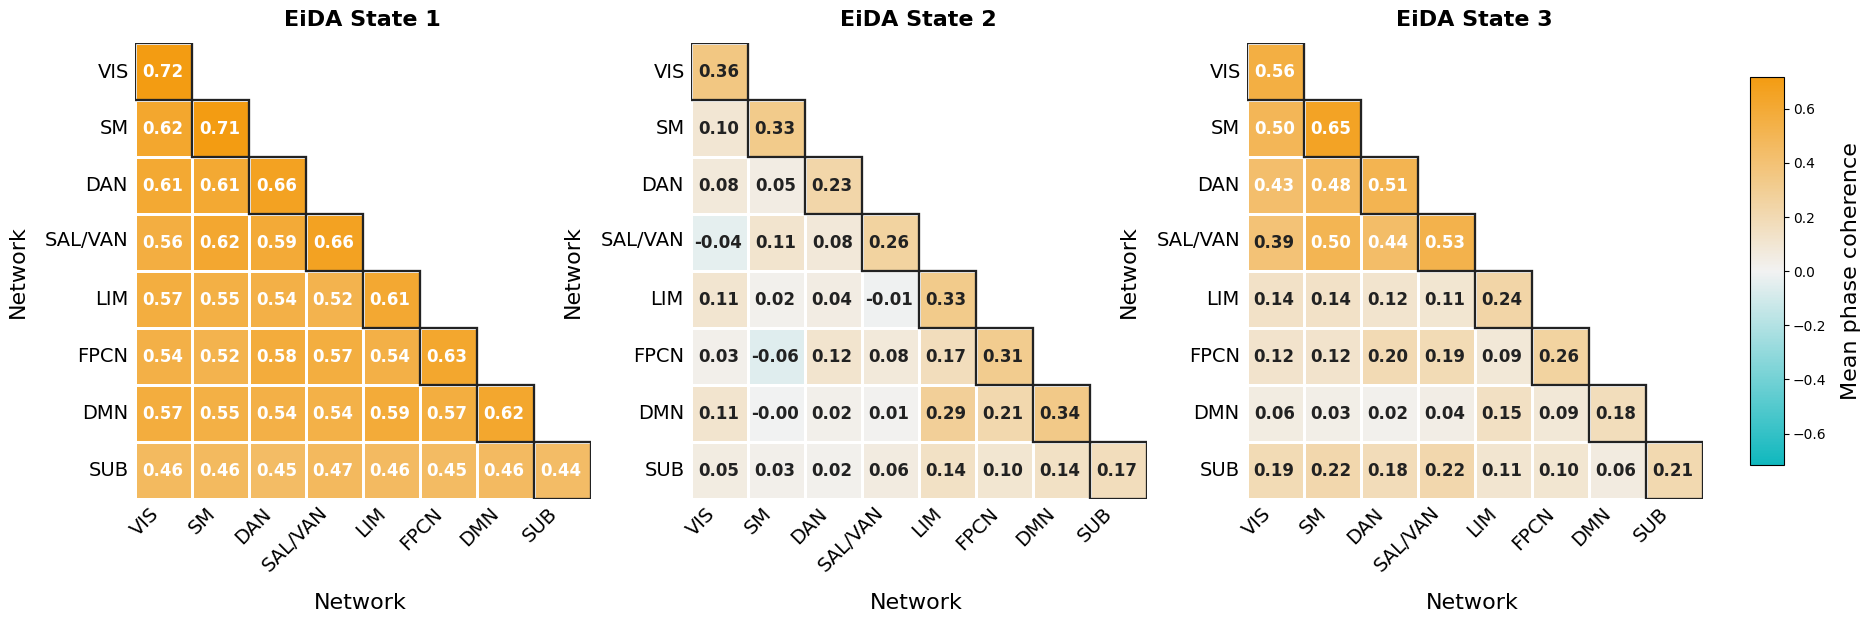

In [33]:
eida_network_matrices = {}

for state in [1, 2, 3]:
    parcel_matrix = state_coherence_matrices[("Discrete EiDA", state)]
    network_matrix = np.empty((len(NETWORK_ORDER), len(NETWORK_ORDER)))

    for i, network_a in enumerate(NETWORK_ORDER):
        for j, network_b in enumerate(NETWORK_ORDER):
            block = parcel_matrix[
                np.ix_(
                    network_indices[network_a],
                    network_indices[network_b],
                )
            ]

            if i == j:
                network_matrix[i, j] = block[
                    np.triu_indices_from(block, k=1)
                ].mean()
            else:
                network_matrix[i, j] = block.mean()

    eida_network_matrices[state] = (
        network_matrix + network_matrix.T
    ) / 2
lower_triangle = np.tril_indices(len(NETWORK_ORDER))

values = np.concatenate([
    matrix[lower_triangle]
    for matrix in eida_network_matrices.values()
])

colour_limit = max(np.abs(values).max(), 1e-12)

colour_norm = Normalize(
    vmin=-colour_limit,
    vmax=colour_limit,
)

phase_cmap = LinearSegmentedColormap.from_list(
    "phase_coherence",
    ["#10B8BE", "#F2F2F2", "#F39C12"],
)

upper_triangle_mask = np.triu(
    np.ones(
        (len(NETWORK_ORDER), len(NETWORK_ORDER)),
        dtype=bool,
    ),
    k=1,
)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 6.8),
    facecolor="white",
)

for axis, state in zip(axes, [1, 2, 3]):
    sns.heatmap(
        eida_network_matrices[state],
        mask=upper_triangle_mask,
        cmap=phase_cmap,
        norm=colour_norm,
        square=True,
        annot=True,
        fmt=".2f",
        linewidths=0.75,
        linecolor="white",
        cbar=False,
        annot_kws={
            "fontsize": 12,
            "fontweight": "semibold",
        },
        xticklabels=NETWORK_SHORT_NAMES,
        yticklabels=NETWORK_SHORT_NAMES,
        ax=axis,
    )

    for text in axis.texts:
        value = float(text.get_text())
        text.set_color(
            "white"
            if abs(value) > 0.58 * colour_limit
            else "#222222"
        )

    for network_index in range(len(NETWORK_ORDER)):
        axis.add_patch(
            Rectangle(
                (network_index, network_index),
                1,
                1,
                fill=False,
                edgecolor="#222222",
                linewidth=1.65,
            )
        )

    axis.set_title(
        f"EiDA State {state}",
        fontsize=16,
        fontweight="semibold",
        pad=13,
    )
    axis.set_xlabel("Network", fontsize=16, labelpad=12)
    axis.set_ylabel("Network", fontsize=16, labelpad=12)
    axis.set_xticklabels(
        NETWORK_SHORT_NAMES,
        rotation=45,
        ha="right",
        fontsize=14,
    )
    axis.set_yticklabels(
        NETWORK_SHORT_NAMES,
        rotation=0,
        fontsize=14,
    )
    axis.tick_params(length=0)


# Shared colour bar
fig.subplots_adjust(
    left=0.065,
    right=0.89,
    top=0.84,
    bottom=0.17,
    wspace=0.22,
)

colourbar_axis = fig.add_axes([
    0.915,
    0.22,
    0.018,
    0.57,
])

colourbar = fig.colorbar(
    ScalarMappable(
        norm=colour_norm,
        cmap=phase_cmap,
    ),
    cax=colourbar_axis,
)

colourbar.set_label(
    "Mean phase coherence",
    fontsize=16,
    labelpad=13,
)
colourbar.ax.tick_params(labelsize=10)

plt.show()